In [13]:
# CELL 1: Global Setup
# ═══════════════════════════════════════════════════════════════════════════════
# All constants, colors, and helpers needed by subsequent cells.
# Canonical: 4 categories (face, house, object, word).
# PPA/TOS split available for future supplemental work (commented out).
# ═══════════════════════════════════════════════════════════════════════════════

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Patch, Ellipse
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.linalg import orthogonal_procrustes
from scipy import stats as sp_stats

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE    = Path(processed_dir)
SEL_DIR = BASE / 'group_results' / 'selectivity'
LIU_DIR = BASE / 'group_results' / 'liu_distinctiveness'
GEO_DIR = BASE / 'group_results' / 'geometry'
FIG_DIR = BASE / 'group_results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Cope set ──────────────────────────────────────────────────────────────────
COPE_SET = 'differential'

# ── Group colors ──────────────────────────────────────────────────────────────
CTRL_L = '#a0a0a0'
CTRL_R = '#505050'
OTC_L  = '#7398af'
OTC_R  = '#ee7183'
NONOT  = '#FF9800'

# ── Categories (canonical: 4) ─────────────────────────────────────────────────
CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL  = ['house', 'object']
UNILATERAL = ['face', 'word']

CAT_COLORS = {
    'face':   '#cc0066',   # magenta
    'word':   '#ff8800',   # orange
    'house':  '#009900',   # green
    'object': '#0077cc',   # blue
}

CAT_MARKERS = {
    'face':   'o',
    'word':   's',
    'house':  '^',
    'object': 'D',
}

# ── Reorganized category per resection side ───────────────────────────────────
REORG = {'left': 'word', 'right': 'face'}

# ── Preferred control hemisphere for Crawford comparisons ─────────────────────
PREFERRED_CTRL_HEMI = {
    'face':   'right',
    'word':   'left',
    'house':  'left',
    'object': 'left',
}

# ── Preferred hemisphere for neural heatmap projection ────────────────────────
PREF_HEMI_NEURAL = {
    'face':   'right',
    'word':   'left',
    'house':  'right',
    'object': 'left',
}

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

RNG = np.random.default_rng(42)

# ── Shared helpers ────────────────────────────────────────────────────────────

def short_name(code):
    """Compact subject label for plot annotations."""
    return (code.replace('OTC', '').replace('nonOTC', 'n')
                .replace('control', 'c').replace('sub-', ''))


def confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    """1-SD covariance ellipse for scatter (x, y). Needs >= 3 points."""
    if len(x) < 3:
        return
    cov     = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry  = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2, **kwargs)
    sx      = np.sqrt(cov[0, 0]) * n_std
    sy      = np.sqrt(cov[1, 1]) * n_std
    t = (transforms.Affine2D()
         .rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)


# ── PPA/TOS extension (peak coords + supplemental) ───────────────────────────
CATEGORIES_PEAK = ['face', 'house_PPA', 'house_TOS', 'object', 'word']
CAT_COLORS_PEAK = {
    **CAT_COLORS,
    'house_PPA': '#005500',   # dark green
    'house_TOS': '#66cc00',   # yellow-green
}
CAT_MARKERS_PEAK = {
    **CAT_MARKERS,
    'house_PPA': '^',
    'house_TOS': 'v',
}
PREFERRED_CTRL_HEMI_PEAK = {
    **PREFERRED_CTRL_HEMI,
    'house_PPA': 'left',
    'house_TOS': 'left',
}

print(f'Setup complete. COPE_SET={COPE_SET}')
print(f'CATEGORIES: {CATEGORIES}')

Setup complete. COPE_SET=differential
CATEGORIES: ['face', 'house', 'object', 'word']


In [14]:
# CELL 2: Crawford Helpers + Shared Data Loaders
# ═══════════════════════════════════════════════════════════════════════════════

def crawford_t(patient_val, ctrl_vals):
    """Crawford & Howell (1998) modified t-test: single case vs controls.
    Returns (t_stat, p_val, n_controls)."""
    ctrl_vals = np.asarray(ctrl_vals)
    ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
    n = len(ctrl_vals)
    if n < 3:
        return np.nan, np.nan, n
    m, s = ctrl_vals.mean(), ctrl_vals.std(ddof=1)
    if s == 0:
        return np.nan, np.nan, n
    t = (patient_val - m) / (s * np.sqrt((n + 1) / n))
    p = 2 * sp_stats.t.sf(abs(t), df=n - 1)
    return t, p, n


def bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction. Returns boolean rejected array."""
    pvals = np.asarray(pvals, dtype=float)
    n     = len(pvals)
    if n == 0: 
        return np.array([], dtype=bool)
    order    = np.argsort(pvals)
    ranked   = np.empty(n)
    ranked[order] = np.arange(1, n + 1)
    threshold = (ranked / n) * alpha
    below = pvals <= threshold
    if not below.any():
        return np.zeros(n, dtype=bool)
    cutoff = pvals[order[np.where(below)[0].max()]]
    return pvals <= cutoff


def load_liu_first_session(cope_set=COPE_SET):
    """Load liu_distinctiveness CSV; return (ctrl, otc) first-session DataFrames."""
    liu_file = LIU_DIR / f'liu_distinctiveness_{cope_set}.csv'
    if not liu_file.exists():
        print(f'  SKIP: {liu_file} not found')
        return None, None
    df    = pd.read_csv(liu_file)
    first = (df.groupby('subject_id')['session'].min()
               .reset_index().rename(columns={'session': 'fs'}))
    df    = df.merge(first, on='subject_id')
    df    = df[df['session'] == df['fs']]
    ctrl  = df[df['status'] == 'control'].copy()
    otc   = df[(df['group'] == 'OTC') & (df['hemi_label'] == 'intact')].copy()
    return ctrl, otc


def compute_crawford_rows(ctrl, otc):
    """Crawford t/p for every patient x category.
    Returns DataFrame: subject, surgery_side, category, t, p, sig (BH-FDR)."""
    rows = []
    for cat in CATEGORIES:
        ref_hemi  = PREFERRED_CTRL_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == ref_hemi)]['liu_distinctiveness'].values
        for _, row in otc[otc['category'] == cat].iterrows():
            t, p, _ = crawford_t(row['liu_distinctiveness'], ctrl_vals)
            rows.append({'subject': row['subject'],
                         'surgery_side': row['surgery_side'],
                         'category': cat, 't': t, 'p': p})
    cdf   = pd.DataFrame(rows)
    valid = cdf['p'].notna()
    cdf['sig'] = False
    if valid.sum() > 0:
        cdf.loc[valid, 'sig'] = bh_fdr(cdf.loc[valid, 'p'].values)
    return cdf


print('Crawford helpers and data loaders ready.')

Crawford helpers and data loaders ready.


Loaded: 961 selectivity rows, 337 percentile rows, 10000 bootstrap iterations
1. CONTROLS LATERALIZATION (LH vs RH per category)
   Paired t-tests, Bonferroni-corrected across 4 categories

  face (more lateralized): n=24
    LH: M=299.4 (SD=227.2)
    RH: M=493.0 (SD=420.6)
    t(23) = -2.914, p = 0.0078, d = -0.608
    Bonferroni (α=0.0125): SIGNIFICANT — RH > LH

  house (more bilateral): n=24
    LH: M=499.5 (SD=325.4)
    RH: M=624.9 (SD=398.7)
    t(23) = -2.764, p = 0.0111, d = -0.576
    Bonferroni (α=0.0125): SIGNIFICANT — RH > LH

  object (more bilateral): n=24
    LH: M=1942.0 (SD=847.3)
    RH: M=1759.7 (SD=895.4)
    t(23) = 2.450, p = 0.0223, d = 0.511
    Bonferroni (α=0.0125): ns — LH > RH

  word (more lateralized): n=24
    LH: M=164.3 (SD=199.3)
    RH: M=29.8 (SD=34.0)
    t(23) = 3.281, p = 0.0033, d = 0.684
    Bonferroni (α=0.0125): SIGNIFICANT — LH > RH

  Summary: All 4 categories show some lateralization.
  Face/word show stronger lateralization (d > 0.6) tha

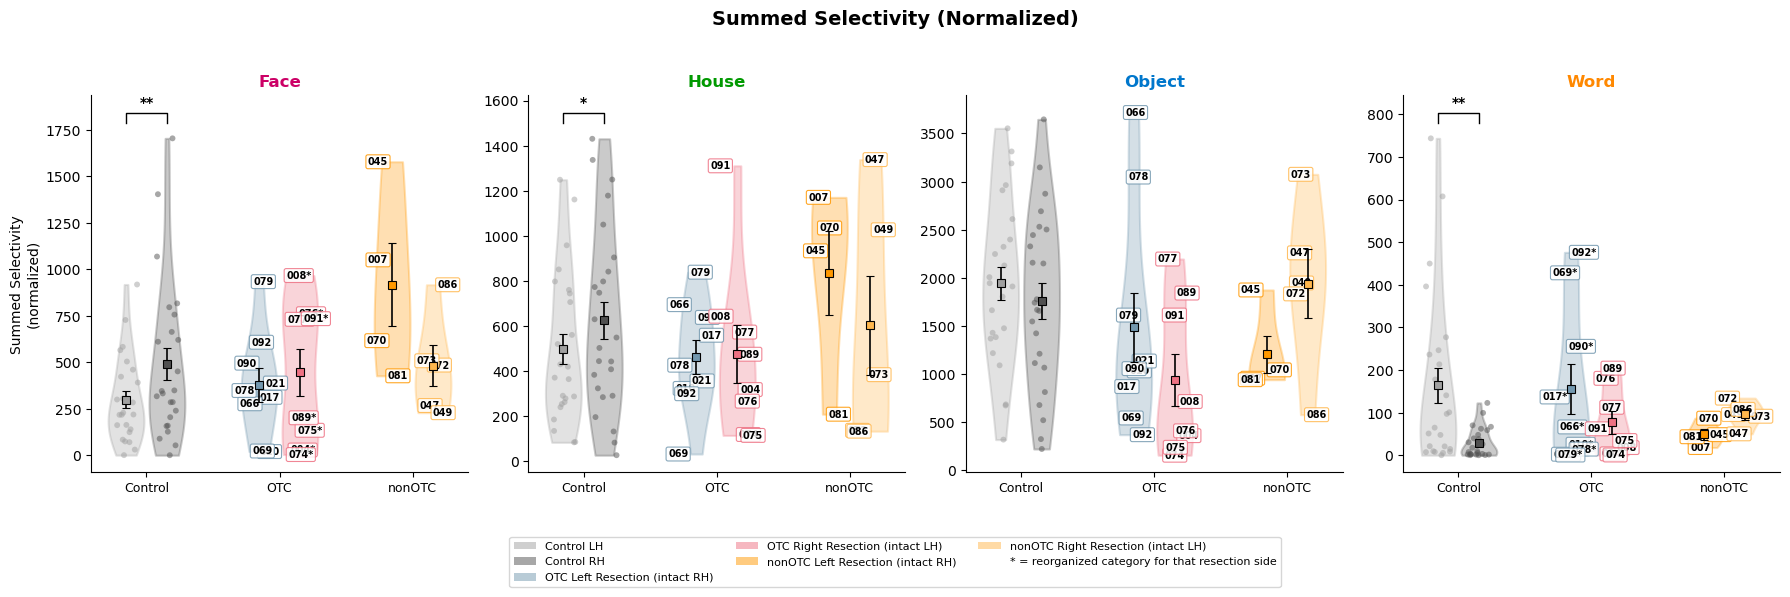

Saved: fig_selectivity_sum_selec_norm.png


In [17]:
# CELL 3: Selectivity — Bootstrap Results + Figure
# ═══════════════════════════════════════════════════════════════════════════════
# Pulls from existing bootstrap pipeline output (03_resample_selectivity.py)
# Reports: bootstrap percentiles, proportion below CI, Cohen's d, lateralization
# Figure: Controls L/R, OTC L/R resection, nonOTC L/R resection
# ═══════════════════════════════════════════════════════════════════════════════

from scipy.stats import ttest_rel, ttest_ind

# ── Load precomputed bootstrap outputs ────────────────────────────────────────
RESAMPLE_DIR = SEL_DIR / 'resamples'
METRIC = 'sum_selec_norm'

sel_file = SEL_DIR / 'selectivity_summary.csv'
pct_file = SEL_DIR / 'patient_percentiles.csv'
resample_file = RESAMPLE_DIR / f'{METRIC}_resamples.csv'

for f, label in [(sel_file, 'selectivity_summary'), (pct_file, 'patient_percentiles'),
                  (resample_file, 'resamples')]:
    if not f.exists():
        print(f'MISSING: {f}')
        print(f'Run 02_calc_summary_vals.py and 03_resample_selectivity.py first')

df_sel = pd.read_csv(sel_file)
df_pct = pd.read_csv(pct_file)
df_boot = pd.read_csv(resample_file)

# First session only
df_sel['ses_int'] = df_sel['ses'].astype(int)
first = df_sel.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
df_sel = df_sel.merge(first, on='sub')
df_sel = df_sel[df_sel['ses_int'] == df_sel['fs']]

ctrl   = df_sel[df_sel['group'] == 'control'].copy()
otc    = df_sel[df_sel['group'] == 'OTC'].copy()
nonotc = df_sel[df_sel['group'] == 'nonOTC'].copy()

otc['surgery_side'] = otc['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')
nonotc['surgery_side'] = nonotc['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')

# Filter percentiles to our metric
pct = df_pct[df_pct['metric'] == METRIC].copy()

# ── Pull age for back-pocket ──────────────────────────────────────────────────
master = _load_csv()
age_df = master[['sub_clean', 'ses_num', 'age']].drop_duplicates()
age_df.columns = ['sub_merge', 'ses_merge', 'age']
age_df['sub_merge'] = age_df['sub_merge'].astype(str)
df_sel['sub_merge'] = df_sel['sub'].astype(str).str.replace('sub-', '')
df_sel = df_sel.merge(age_df, left_on=['sub_merge', 'ses_int'],
                       right_on=['sub_merge', 'ses_merge'], how='left')

ctrl_age   = df_sel[df_sel['group'] == 'control'].groupby('sub')['age'].first()
otc_age    = df_sel[df_sel['group'] == 'OTC'].groupby('sub')['age'].first()
nonotc_age = df_sel[df_sel['group'] == 'nonOTC'].groupby('sub')['age'].first()

print(f'Loaded: {len(df_sel)} selectivity rows, {len(pct)} percentile rows, '
      f'{len(df_boot)} bootstrap iterations')

# ══════════════════════════════════════════════════════════════════════════════
# 1. CONTROLS LATERALIZATION
# ══════════════════════════════════════════════════════════════════════════════
print('='*70)
print('1. CONTROLS LATERALIZATION (LH vs RH per category)')
print('   Paired t-tests, Bonferroni-corrected across 4 categories')
print('='*70)

n_comparisons = len(CATEGORIES)
bonferroni_alpha = 0.05 / n_comparisons

ctrl_wide = {}
for cat in CATEGORIES:
    cat_df = ctrl[ctrl['category'] == cat][['sub', 'hemi', METRIC]]
    pivoted = cat_df.pivot(index='sub', columns='hemi', values=METRIC).dropna()
    ctrl_wide[cat] = pivoted

for cat in CATEGORIES:
    piv = ctrl_wide[cat]
    if len(piv) < 3:
        continue
    lh, rh = piv['left'].values, piv['right'].values
    n = len(lh)
    diff = lh - rh

    t_stat, t_p = ttest_rel(lh, rh)
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan

    bonf_sig = t_p < bonferroni_alpha
    direction = 'LH > RH' if diff.mean() > 0 else 'RH > LH'
    cat_type = 'more lateralized' if cat in UNILATERAL else 'more bilateral'

    print(f'\n  {cat} ({cat_type}): n={n}')
    print(f'    LH: M={lh.mean():.1f} (SD={lh.std():.1f})')
    print(f'    RH: M={rh.mean():.1f} (SD={rh.std():.1f})')
    print(f'    t({n-1}) = {t_stat:.3f}, p = {t_p:.4f}, d = {d:.3f}')
    print(f'    Bonferroni (α={bonferroni_alpha:.4f}): '
          f'{"SIGNIFICANT" if bonf_sig else "ns"} — {direction}')

print(f'\n  Summary: All 4 categories show some lateralization.')
print(f'  Face/word show stronger lateralization (d > 0.6) than object/house (d ~ 0.5).')
print(f'  This is consistent with graded, not binary, hemispheric specialization')
print(f'  (Behrmann & Plaut, 2015).')

# ══════════════════════════════════════════════════════════════════════════════
# 2. INDIVIDUAL PATIENT BOOTSTRAP RESULTS (from pipeline)
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('2. INDIVIDUAL PATIENT BOOTSTRAP RESULTS')
print('   Each patient vs. bootstrapped control 95% CI (Ayzenberg method)')
print('   * = below 2.5th percentile of bootstrapped control distribution')
print('='*70)

for grp_label in ['OTC', 'nonOTC']:
    grp_pct = pct[pct['group'] == grp_label]
    if grp_pct.empty:
        continue
    print(f'\n--- {grp_label} ---')
    for sub in sorted(grp_pct['sub'].unique()):
        sub_data = grp_pct[grp_pct['sub'] == sub]
        intact = sub_data['intact_hemi'].iloc[0]
        line = f'  {sub} (intact {intact}): '
        for _, r in sub_data.iterrows():
            marker = '*' if r['below_ci'] else '-'
            line += f'{r["category"]}={r["value"]:.0f}({r["percentile"]:.0f}%){marker} '
        print(line)

    # Summary: proportion below CI per category
    print(f'\n  Proportion below CI per category:')
    for cat in CATEGORIES:
        cat_data = grp_pct[grp_pct['category'] == cat]
        n_total = len(cat_data)
        n_below = cat_data['below_ci'].sum() if n_total > 0 else 0
        pct_below = (n_below / n_total * 100) if n_total > 0 else 0
        print(f'    {cat}: {int(n_below)}/{n_total} ({pct_below:.0f}%)')

# ══════════════════════════════════════════════════════════════════════════════
# 3. GROUP-LEVEL COMPARISONS (bootstrap + Cohen's d)
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('3. GROUP-LEVEL BOOTSTRAP COMPARISONS')
print('   Patient group mean vs. bootstrapped control distribution')
print('   + Cohen\'s d (patient group mean vs. control mean)')
print('='*70)

for grp_label, grp_df in [('OTC', otc), ('nonOTC', nonotc)]:
    print(f'\n--- {grp_label} vs Controls ---')
    for cat in CATEGORIES:
        # Patient values (intact hemisphere)
        pt_vals = grp_df[grp_df['category'] == cat][METRIC].dropna().values
        if len(pt_vals) == 0:
            continue

        pt_mean = pt_vals.mean()

        # Get matched control hemisphere bootstrap distribution
        # Patients have mixed L/R intact — get control distribution for each
        # and combine, weighted by patient composition
        pt_hemis = grp_df[grp_df['category'] == cat]['hemi'].values

        # Control raw values (hemisphere-matched)
        ctrl_vals = []
        for h in np.unique(pt_hemis):
            cv = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == h)][METRIC].values
            ctrl_vals.extend(cv)
        ctrl_vals = np.array(ctrl_vals)
        ctrl_mean = ctrl_vals.mean()
        ctrl_sd = ctrl_vals.std(ddof=1)

        # Bootstrap: use the stored bootstrapped means for each hemi
        # Average across relevant hemispheres
        boot_cols = []
        for h in np.unique(pt_hemis):
            col = f'{cat}_{h}'
            if col in df_boot.columns:
                boot_cols.append(df_boot[col].values)

        if boot_cols:
            # Combine bootstrap distributions (average if multiple hemis)
            boot_combined = np.mean(boot_cols, axis=0)
            pt_pctile = float(np.mean(boot_combined <= pt_mean) * 100)
            ci_lo = np.percentile(boot_combined, 2.5)
            ci_hi = np.percentile(boot_combined, 97.5)
            below = pt_mean < ci_lo
        else:
            pt_pctile, ci_lo, ci_hi, below = np.nan, np.nan, np.nan, False

        # Cohen's d
        pooled_sd = ctrl_sd  # Use control SD as denominator (Glass's delta)
        d = (pt_mean - ctrl_mean) / pooled_sd if pooled_sd > 0 else np.nan

        sig_str = '**BELOW CI**' if below else 'within CI'

        print(f'  {cat}: pt M={pt_mean:.1f} (n={len(pt_vals)}), '
              f'ctrl M={ctrl_mean:.1f} (n={len(ctrl_vals)})')
        print(f'    Bootstrap: pctile={pt_pctile:.1f}%, '
              f'95% CI=[{ci_lo:.1f}, {ci_hi:.1f}] — {sig_str}')
        print(f'    Glass\'s Δ = {d:.3f}')

# ══════════════════════════════════════════════════════════════════════════════
# 4. DESCRIPTIVES
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('4. DESCRIPTIVES')
print('='*70)

for grp_label, grp_df, age_series in [
    ('Control', ctrl, ctrl_age), ('OTC', otc, otc_age), ('nonOTC', nonotc, nonotc_age)
]:
    age_str = ''
    if len(age_series.dropna()) > 0:
        age_str = f' | age M={age_series.mean():.1f}, SD={age_series.std():.1f}'
    print(f'\n--- {grp_label} (n={grp_df["sub"].nunique()}){age_str} ---')
    for cat in CATEGORIES:
        if grp_label == 'Control':
            for hemi in ['left', 'right']:
                vals = grp_df[(grp_df['category'] == cat) &
                              (grp_df['hemi'] == hemi)][METRIC].dropna()
                if len(vals) > 0:
                    print(f'  {cat} {hemi}: M={vals.mean():.1f}, SD={vals.std():.1f}, n={len(vals)}')
        else:
            vals = grp_df[grp_df['category'] == cat][METRIC].dropna()
            if len(vals) > 0:
                print(f'  {cat} (intact): M={vals.mean():.1f}, SD={vals.std():.1f}, n={len(vals)}')

# ══════════════════════════════════════════════════════════════════════════════
# BACK POCKET: Age group comparisons
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('BACK POCKET: Age comparison between groups')
print('='*70)

for grp_label, grp_age in [('OTC', otc_age), ('nonOTC', nonotc_age)]:
    if len(grp_age.dropna()) > 0 and len(ctrl_age.dropna()) > 0:
        t, p = ttest_ind(ctrl_age.dropna(), grp_age.dropna())
        print(f'  Control vs {grp_label}: t={t:.3f}, p={p:.4f}')
        print(f'    Control: M={ctrl_age.mean():.1f}, SD={ctrl_age.std():.1f}, n={len(ctrl_age.dropna())}')
        print(f'    {grp_label}: M={grp_age.mean():.1f}, SD={grp_age.std():.1f}, n={len(grp_age.dropna())}')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════

n_cats = len(CATEGORIES)
fig, axes = plt.subplots(1, n_cats, figsize=(4.5 * n_cats, 5.5), sharey=False)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]
    vd, vp, vc = [], [], []

    # ── Controls L/R ──────────────────────────────────────────────────────
    cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'left')][METRIC].values
    cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'right')][METRIC].values

    for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
        if len(vals) < 2:
            continue
        vd.append(vals); vp.append(pos); vc.append(color)
        jit = RNG.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
        ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── OTC Left/Right resection ──────────────────────────────────────────
    for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
        sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(color)
        for _, row in sd.iterrows():
            jit  = RNG.uniform(-0.18, 0.18)
            lbl  = short_name(row['sub'])
            # Asterisk = reorganized category for this resection side
            star = '*' if REORG.get(side) == cat else ''
            ax.annotate(f'{lbl}{star}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=color, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── nonOTC Left/Right resection ───────────────────────────────────────
    for side, pos, base_color in [('left', 2.6, NONOT), ('right', 3.0, NONOT)]:
        sd = nonotc[(nonotc['category'] == cat) & (nonotc['surgery_side'] == side)]
        vals = sd[METRIC].values
        face_color = NONOT if side == 'left' else '#FFB74D'
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(face_color)
        for _, row in sd.iterrows():
            jit = RNG.uniform(-0.18, 0.18)
            lbl = short_name(row['sub'])
            ax.annotate(f'{lbl}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=face_color, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=face_color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── Violins ───────────────────────────────────────────────────────────
    if vd:
        vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                              showmedians=False, showextrema=False, widths=0.35)
        for i, body in enumerate(vplot['bodies']):
            body.set_facecolor(vc[i]); body.set_alpha(0.3)
            body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

    # ── Lateralization bracket (controls) ─────────────────────────────────
    if cat in ctrl_wide and len(ctrl_wide[cat]) >= 3:
        piv = ctrl_wide[cat]
        _, lat_p = ttest_rel(piv['left'].values, piv['right'].values)
        if lat_p < (0.05 / n_comparisons):  # Bonferroni threshold
            y_max = max(cl.max() if len(cl) > 0 else 0,
                        cr.max() if len(cr) > 0 else 0)
            bracket_y = y_max * 1.05
            ax.plot([0.0, 0.0, 0.4, 0.4],
                    [bracket_y, bracket_y * 1.03, bracket_y * 1.03, bracket_y],
                    color='black', linewidth=1, clip_on=False)
            sig_str = '***' if lat_p < 0.001 else '**' if lat_p < 0.01 else '*'
            ax.text(0.2, bracket_y * 1.04, sig_str,
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks([0.2, 1.5, 2.8])
    ax.set_xticklabels(['Control', 'OTC', 'nonOTC'], fontsize=9)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold',
                 color=CAT_COLORS[cat])
    if col_idx == 0:
        ax.set_ylabel('Summed Selectivity\n(normalized)')

# ── Legend ─────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.5, label='Control LH'),
    Patch(facecolor=CTRL_R, alpha=0.5, label='Control RH'),
    Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection (intact RH)'),
    Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection (intact LH)'),
    Patch(facecolor=NONOT,  alpha=0.5, label='nonOTC Left Resection (intact RH)'),
    Patch(facecolor='#FFB74D', alpha=0.5, label='nonOTC Right Resection (intact LH)'),
    Line2D([0], [0], marker='None', color='none',
           label='* = reorganized category for that resection side'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Summed Selectivity (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_selectivity_{METRIC}.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_selectivity_{METRIC}.png')

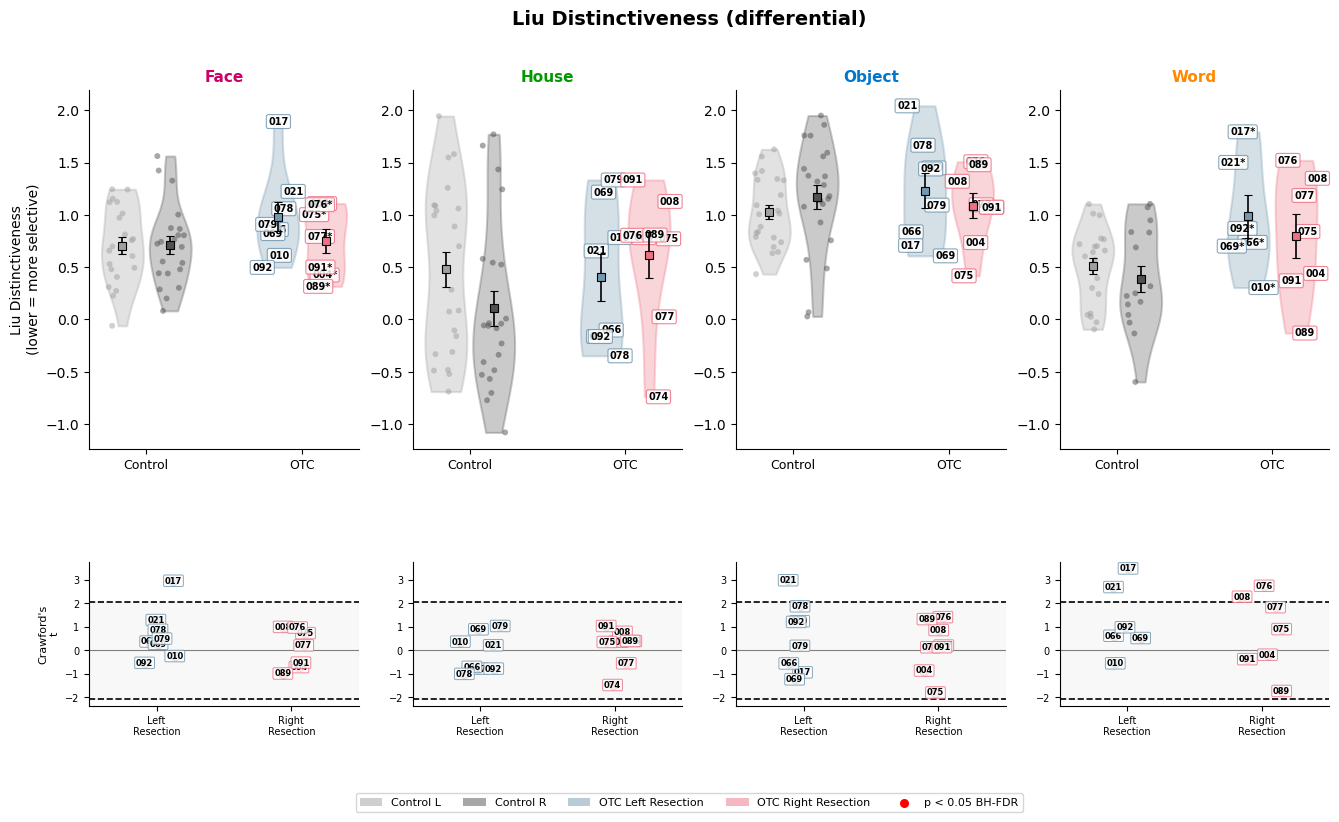

  Saved: fig_liu_differential.png


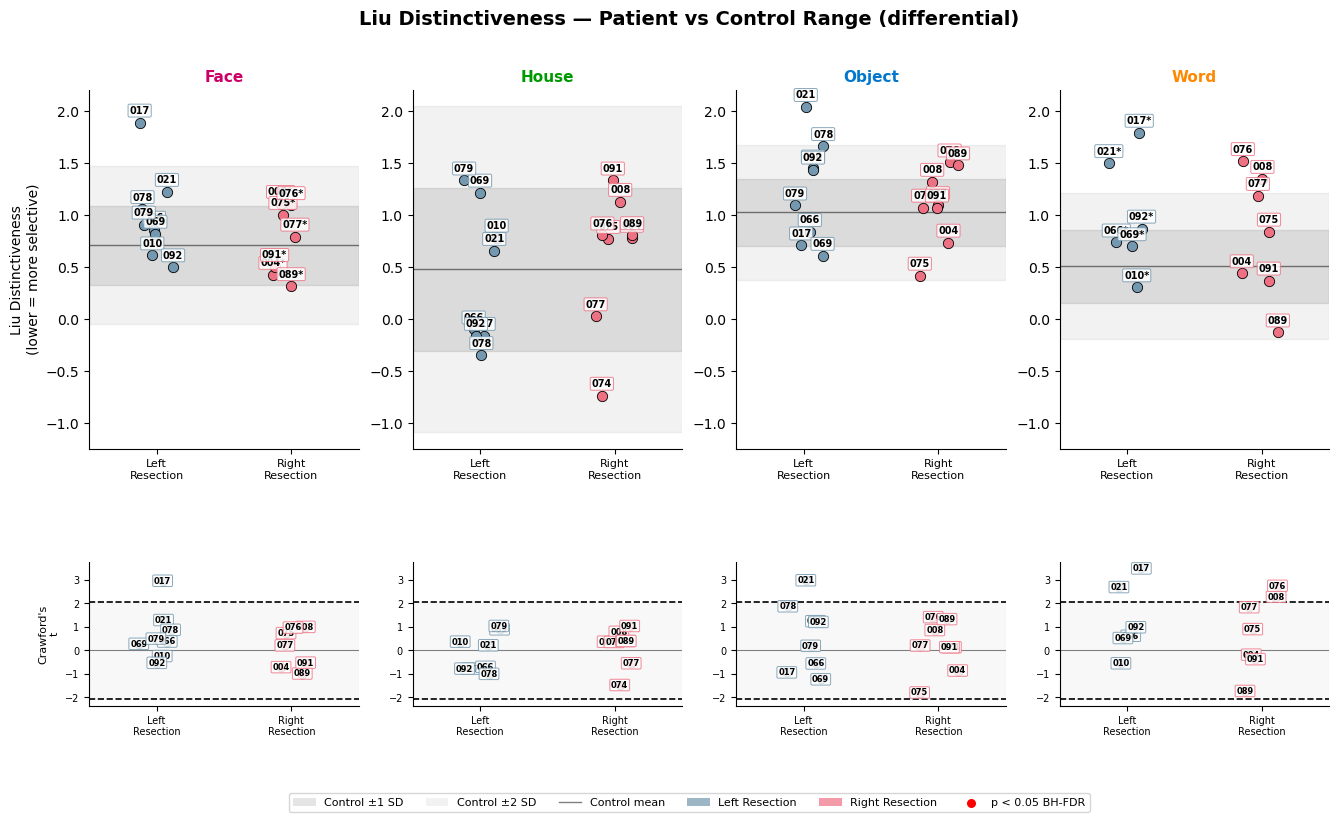

  Saved: fig_liu_range_differential.png


In [5]:
# CELL 4: Liu Distinctiveness — violin+jitter (4-panel) and Liu-style (1-axis)
# ═══════════════════════════════════════════════════════════════════════════════

def fig_liu_distinctiveness(cope_set=COPE_SET):
    """One panel per category: violin + jitter for controls, labeled badges
    for patients, Crawford t-score strip below."""
    ctrl, otc = load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf    = compute_crawford_rows(ctrl, otc)
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = sp_stats.t.ppf(0.975, df=n_ctrl - 1)

    n_cats = len(CATEGORIES)
    fig    = plt.figure(figsize=(4 * n_cats, 8))
    gs     = fig.add_gridspec(2, n_cats, height_ratios=[3, 1.2], hspace=0.45)

    ax_top0, ax_bot0 = None, None
    for col_idx, cat in enumerate(CATEGORIES):
        ax  = fig.add_subplot(gs[0, col_idx], sharey=ax_top0)
        axc = fig.add_subplot(gs[1, col_idx], sharey=ax_bot0)
        if col_idx == 0:
            ax_top0, ax_bot0 = ax, axc
        color = CAT_COLORS[cat]

        # ── Top: violin + jitter ──────────────────────────────────────────────
        vd, vp, vc = [], [], []
        cl = ctrl[(ctrl['category'] == cat) &
                  (ctrl['hemi_label'] == 'left')]['liu_distinctiveness'].values
        cr = ctrl[(ctrl['category'] == cat) &
                  (ctrl['hemi_label'] == 'right')]['liu_distinctiveness'].values

        for vals, pos, c in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(c)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=c, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=c, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        for side, pos, c in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd['liu_distinctiveness'].values
            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(c)
            for _, row in sd.iterrows():
                jit  = RNG.uniform(-0.18, 0.18)
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f"{short_name(row['subject'])}{star}",
                            (pos + jit, row['liu_distinctiveness']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=c, alpha=0.85, linewidth=0.8),
                            zorder=4)
            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals),
                            yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=c, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for body, vc_i in zip(vplot['bodies'], vc):
                body.set_facecolor(vc_i); body.set_alpha(0.3)
                body.set_edgecolor(vc_i); body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=11, fontweight='bold', color=color)
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')

        # ── Bottom: Crawford t-scores ─────────────────────────────────────────
        cat_cdf = cdf[cdf['category'] == cat]
        axc.axhline(0,        color='gray',  linewidth=0.8)
        axc.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--')
        axc.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--')
        axc.axhspan(-t_crit, t_crit, alpha=0.05, color='gray')

        for _, r in cat_cdf.iterrows():
            if np.isnan(r['t']):
                continue
            x   = {'left': 0.0, 'right': 1.0}[r['surgery_side']] + RNG.uniform(-0.15, 0.15)
            c   = OTC_L if r['surgery_side'] == 'left' else OTC_R
            dot = 'red' if r['sig'] else c
            axc.scatter(x, r['t'], color=dot, s=40, zorder=4,
                        edgecolors='black', linewidth=0.5)
            axc.annotate(short_name(r['subject']), (x, r['t']),
                         fontsize=6, fontweight='bold', ha='center', va='center',
                         bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                                   edgecolor=dot, alpha=0.85, linewidth=0.7),
                         zorder=5)

        axc.set_xlim(-0.5, 1.5)
        axc.set_xticks([0.0, 1.0])
        axc.set_xticklabels(['Left\nResection', 'Right\nResection'], fontsize=7)
        if col_idx == 0:
            axc.set_ylabel("Crawford's\nt", fontsize=8)
        axc.tick_params(axis='y', labelsize=7)

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
        plt.scatter([], [], color='red', s=30, label='p < 0.05 BH-FDR'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=5,
               fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.03))
    plt.suptitle(f'Liu Distinctiveness ({cope_set})', fontsize=14, fontweight='bold')
    plt.savefig(str(FIG_DIR / f'fig_liu_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_liu_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_liu_distinctiveness(COPE_SET)


def fig_liu_range(cope_set=COPE_SET):
    """Patient dots against control mean +/- 1-2 SD bands, one panel per category,
    with Crawford t-score strip below."""
    ctrl, otc = load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf    = compute_crawford_rows(ctrl, otc)
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = sp_stats.t.ppf(0.975, df=n_ctrl - 1)

    n_cats = len(CATEGORIES)
    fig    = plt.figure(figsize=(4 * n_cats, 8))
    gs     = fig.add_gridspec(2, n_cats, height_ratios=[3, 1.2], hspace=0.45)

    ax_top0, ax_bot0 = None, None
    for col_idx, cat in enumerate(CATEGORIES):
        ax  = fig.add_subplot(gs[0, col_idx], sharey=ax_top0)
        axc = fig.add_subplot(gs[1, col_idx], sharey=ax_bot0)
        if col_idx == 0:
            ax_top0, ax_bot0 = ax, axc
        color = CAT_COLORS[cat]

        # ── Top: control range + patient dots ─────────────────────────────────
        ref_hemi  = PREFERRED_CTRL_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == ref_hemi)]['liu_distinctiveness'].values

        if len(ctrl_vals) >= 2:
            m, s = np.mean(ctrl_vals), np.std(ctrl_vals)
            ax.axhspan(m - 2*s, m + 2*s, color='gray', alpha=0.10, zorder=0,
                       label='\u00b12 SD' if col_idx == 0 else '')
            ax.axhspan(m - s, m + s, color='gray', alpha=0.20, zorder=1,
                       label='\u00b11 SD' if col_idx == 0 else '')
            ax.axhline(m, color='black', linewidth=1.0, linestyle='-',
                       alpha=0.5, zorder=2)

        # Patient dots — left resection on x=0, right on x=1
        for side, x_pos, c in [('left', 0.0, OTC_L), ('right', 1.0, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            for _, row in sd.iterrows():
                jit  = RNG.uniform(-0.15, 0.15)
                star = '*' if REORG.get(side) == cat else ''
                ax.scatter(x_pos + jit, row['liu_distinctiveness'],
                           color=c, s=55, zorder=4,
                           edgecolors='black', linewidth=0.6)
                ax.annotate(f"{short_name(row['subject'])}{star}",
                            (x_pos + jit, row['liu_distinctiveness']),
                            fontsize=7, fontweight='bold', ha='center', va='bottom',
                            xytext=(0, 5), textcoords='offset points',
                            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                                      edgecolor=c, alpha=0.85, linewidth=0.7),
                            zorder=5)

        ax.set_xlim(-0.5, 1.5)
        ax.set_xticks([0.0, 1.0])
        ax.set_xticklabels(['Left\nResection', 'Right\nResection'], fontsize=8)
        ax.set_title(cat.title(), fontsize=11, fontweight='bold', color=color)
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')

        # ── Bottom: Crawford t-scores ─────────────────────────────────────────
        cat_cdf = cdf[cdf['category'] == cat]
        axc.axhline(0,        color='gray',  linewidth=0.8)
        axc.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--')
        axc.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--')
        axc.axhspan(-t_crit, t_crit, alpha=0.05, color='gray')

        for _, r in cat_cdf.iterrows():
            if np.isnan(r['t']):
                continue
            x   = {'left': 0.0, 'right': 1.0}[r['surgery_side']] + RNG.uniform(-0.15, 0.15)
            c   = OTC_L if r['surgery_side'] == 'left' else OTC_R
            dot = 'red' if r['sig'] else c
            axc.scatter(x, r['t'], color=dot, s=40, zorder=4,
                        edgecolors='black', linewidth=0.5)
            axc.annotate(short_name(r['subject']), (x, r['t']),
                         fontsize=6, fontweight='bold', ha='center', va='center',
                         bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                                   edgecolor=dot, alpha=0.85, linewidth=0.7),
                         zorder=5)

        axc.set_xlim(-0.5, 1.5)
        axc.set_xticks([0.0, 1.0])
        axc.set_xticklabels(['Left\nResection', 'Right\nResection'], fontsize=7)
        if col_idx == 0:
            axc.set_ylabel("Crawford's\nt", fontsize=8)
        axc.tick_params(axis='y', labelsize=7)

    legend_elements = [
        Patch(facecolor='gray', alpha=0.20, label='Control \u00b11 SD'),
        Patch(facecolor='gray', alpha=0.10, label='Control \u00b12 SD'),
        Line2D([0], [0], color='black', linewidth=1.0, alpha=0.5, label='Control mean'),
        Patch(facecolor=OTC_L, alpha=0.7, label='Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.7, label='Right Resection'),
        plt.scatter([], [], color='red', s=30, label='p < 0.05 BH-FDR'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=6,
               fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.03))
    plt.suptitle(f'Liu Distinctiveness \u2014 Patient vs Control Range ({cope_set})',
                 fontsize=14, fontweight='bold')
    plt.savefig(str(FIG_DIR / f'fig_liu_range_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_liu_range_{cope_set}.png')


fig_liu_range(COPE_SET)

  [DEBUG] Categories Plot - Plotting subjects: ['OTC004', 'OTC008', 'OTC010', 'OTC021', 'OTC079']


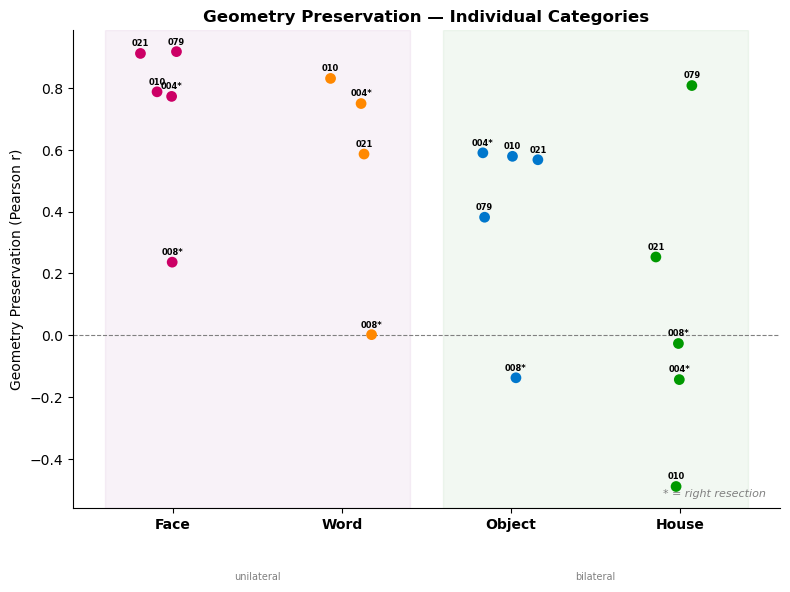

  Saved: fig_geometry_categories_differential.png
  [DEBUG] Slope Plot - Plotting subjects: ['OTC004', 'OTC008', 'OTC010', 'OTC021', 'OTC079']


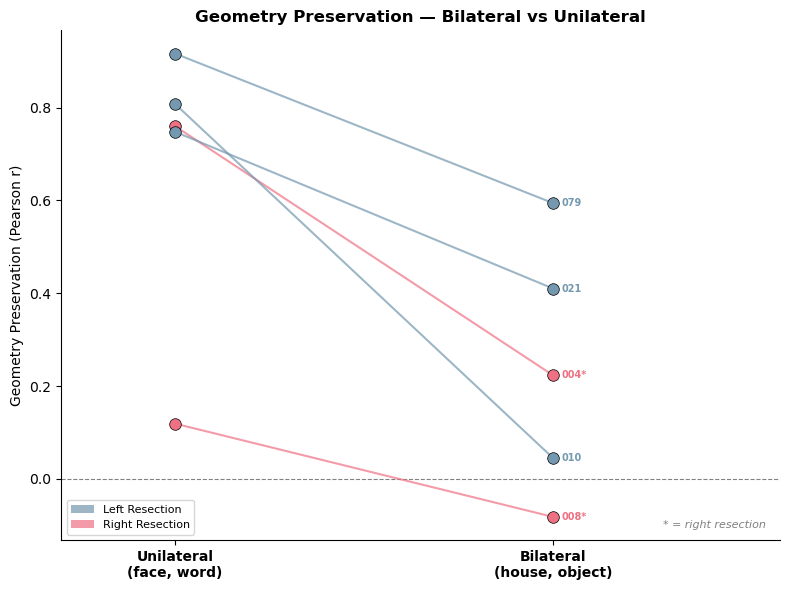

  Saved: fig_geometry_slope_differential.png


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: Geometry Preservation — Bilateral vs Unilateral (HEADLINE)
# ═══════════════════════════════════════════════════════════════════════════════

def fig_geometry_categories(cope_set=COPE_SET):
    """Individual category dots per patient, no connecting lines.
    Right resection patients marked with asterisk."""

    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not geo_file.exists():
        print(f'  SKIP: {geo_file} not found')
        return

    geo = pd.read_csv(geo_file)
    
    # Robust exclusion: drops any subject containing '017'
    geo = geo[~geo['subject'].astype(str).str.contains('017')]
    
    otc = geo[(geo['group'] == 'OTC') & (geo['hemi_label'] == 'intact')]

    fig, ax = plt.subplots(figsize=(8, 6))

    subs = sorted(otc['subject'].unique())
    print(f"  [DEBUG] Categories Plot - Plotting subjects: {subs}")

    cat_order = ['face', 'word', 'object', 'house']
    cat_x = {cat: i for i, cat in enumerate(cat_order)}

    for sub in subs:
        sub_df = otc[otc['subject'] == sub]
        side   = sub_df['surgery_side'].iloc[0]
        lbl    = short_name(sub)
        star   = '*' if side == 'right' else ''
        for cat in cat_order:
            cv = sub_df[sub_df['category'] == cat]['geometry_preservation'].values
            v  = cv[0] if len(cv) else np.nan
            if np.isfinite(v):
                jit = RNG.uniform(-0.2, 0.2)
                ax.scatter(cat_x[cat] + jit, v, color=CAT_COLORS[cat],
                           s=60, zorder=4, edgecolors='none')
                ax.annotate(f'{lbl}{star}', (cat_x[cat] + jit, v),
                            fontsize=6, fontweight='bold', ha='center',
                            va='bottom', xytext=(0, 4),
                            textcoords='offset points', color='black')

    # Shade bilateral vs unilateral regions
    ax.axvspan(-0.4, 1.4, alpha=0.05, color='purple', zorder=0)
    ax.axvspan(1.6, 3.4, alpha=0.05, color='green', zorder=0)
    ax.text(0.5, -0.15, 'unilateral', ha='center', fontsize=7, color='gray',
            transform=ax.get_xaxis_transform())
    ax.text(2.5, -0.15, 'bilateral', ha='center', fontsize=7, color='gray',
            transform=ax.get_xaxis_transform())

    ax.set_xticks(range(len(cat_order)))
    ax.set_xticklabels([c.title() for c in cat_order], fontsize=10, fontweight='bold')
    ax.set_ylabel('Geometry Preservation (Pearson r)', fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)
    ax.set_title('Geometry Preservation — Individual Categories', fontsize=12,
                 fontweight='bold')

    ax.annotate('* = right resection', xy=(0.98, 0.02), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=8, color='gray', style='italic')

    plt.tight_layout()
    plt.savefig(str(FIG_DIR / f'fig_geometry_categories_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_geometry_categories_{cope_set}.png')


def fig_geometry_slope(cope_set=COPE_SET):
    """Paired slope: unilateral mean to bilateral mean per patient.
    Right resection patients marked with asterisk."""

    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not geo_file.exists():
        print(f'  SKIP: {geo_file} not found')
        return

    geo = pd.read_csv(geo_file)
    
    # Robust exclusion: drops any subject containing '017'
    geo = geo[~geo['subject'].astype(str).str.contains('017')]
    
    otc = geo[(geo['group'] == 'OTC') & (geo['hemi_label'] == 'intact')]

    fig, ax = plt.subplots(figsize=(8, 6))

    subs = sorted(otc['subject'].unique())
    print(f"  [DEBUG] Slope Plot - Plotting subjects: {subs}")

    for sub in subs:
        sub_df = otc[otc['subject'] == sub]
        side   = sub_df['surgery_side'].iloc[0]
        col    = OTC_L if side == 'left' else OTC_R
        lbl    = short_name(sub)
        star   = '*' if side == 'right' else ''

        uni_vals = [sub_df[sub_df['category'] == c]['geometry_preservation'].values
                    for c in UNILATERAL]
        bil_vals = [sub_df[sub_df['category'] == c]['geometry_preservation'].values
                    for c in BILATERAL]
        uni = np.nanmean([v[0] for v in uni_vals if len(v)])
        bil = np.nanmean([v[0] for v in bil_vals if len(v)])

        if not (np.isfinite(uni) and np.isfinite(bil)):
            continue

        ax.plot([0, 1], [uni, bil], color=col, linewidth=1.5,
                alpha=0.7, zorder=3)
        ax.scatter(0, uni, color=col, s=70, zorder=4,
                   edgecolors='black', linewidth=0.5)
        ax.scatter(1, bil, color=col, s=70, zorder=4,
                   edgecolors='black', linewidth=0.5)
        ax.annotate(f'{lbl}{star}', (1, bil), fontsize=7, fontweight='bold',
                    ha='left', va='center', xytext=(6, 0),
                    textcoords='offset points', color=col)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Unilateral\n(face, word)',
                         'Bilateral\n(house, object)'],
                        fontsize=10, fontweight='bold')
    ax.set_ylabel('Geometry Preservation (Pearson r)', fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)
    ax.set_xlim(-0.3, 1.6)
    ax.set_title('Geometry Preservation — Bilateral vs Unilateral',
                 fontsize=12, fontweight='bold')

    ax.legend(handles=[
        Patch(facecolor=OTC_L, alpha=0.7, label='Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.7, label='Right Resection'),
    ], loc='lower left', fontsize=8, frameon=True)

    ax.annotate('* = right resection', xy=(0.98, 0.02), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=8, color='gray', style='italic')

    plt.tight_layout()
    plt.savefig(str(FIG_DIR / f'fig_geometry_slope_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_geometry_slope_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_geometry_categories(COPE_SET)
fig_geometry_slope(COPE_SET)

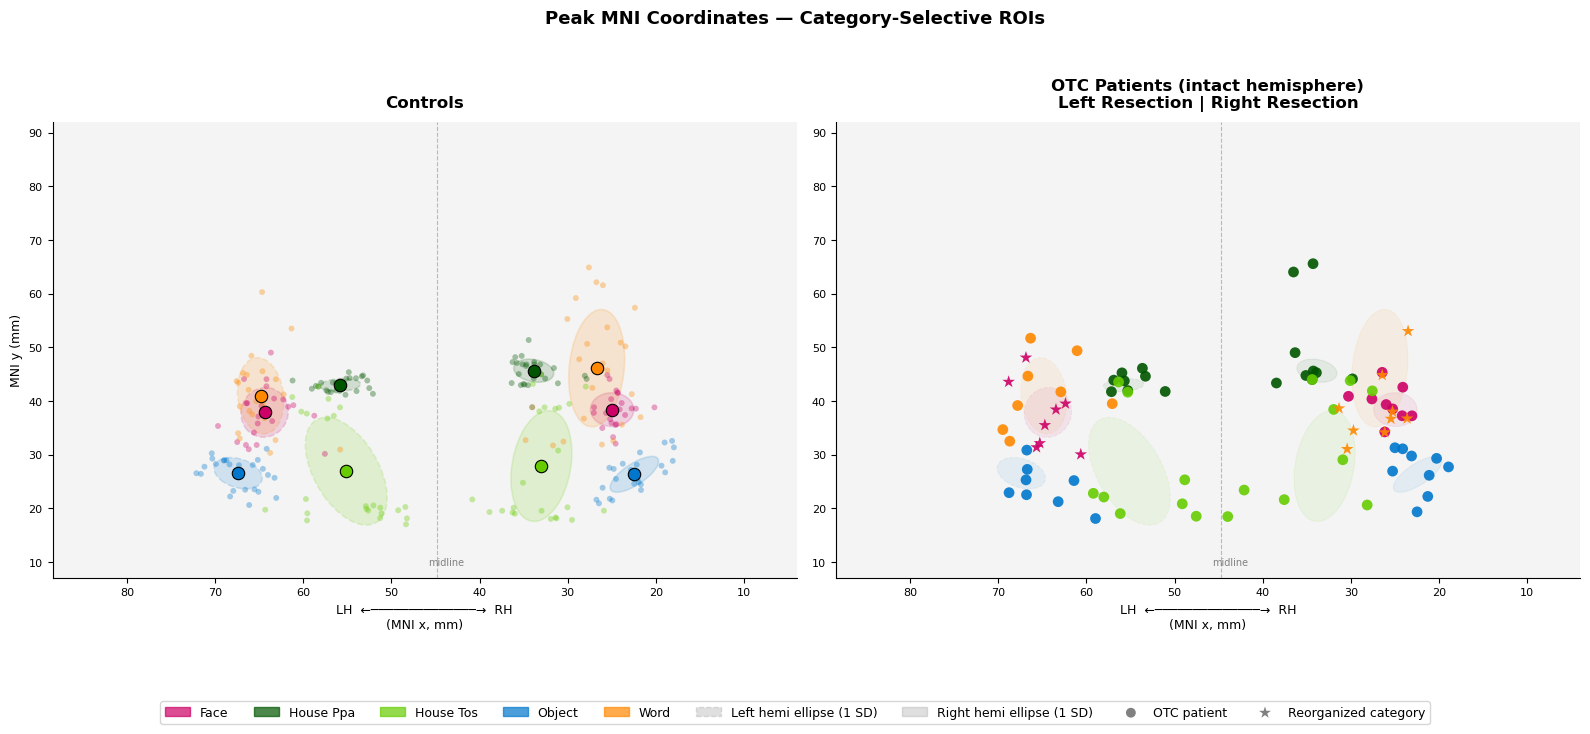

  Saved: fig_peak_coords.png


In [7]:
# CELL 5: Peak MNI Coordinates — dot + star for reorganized category
# ═══════════════════════════════════════════════════════════════════════════════

def fig_peak_coordinates(suffix=''):
    """Liu Fig.2-style 2D MNI scatter (uses PPA/TOS split for house).
    Controls: 1-SD ellipses per hemi + small dots + centroid.
    Patients: circles (star = reorganized category only)."""

    pk_file = BASE / 'group_results' / 'peak_coords' / f'peak_coords{suffix}.csv'
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    cats = CATEGORIES_PEAK

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)
    first = (df.groupby('sub')['ses_int'].min()
               .reset_index().rename(columns={'ses_int': 'fs'}))
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    otc = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
              ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    lx = ctrl[ctrl['hemi'] == 'left']['peak_x_mni'].mean()
    rx = ctrl[ctrl['hemi'] == 'right']['peak_x_mni'].mean()
    midline_x = (lx + rx) / 2

    pad  = 10
    xlim = (ctrl['peak_x_mni'].min() - pad, ctrl['peak_x_mni'].max() + pad)
    ylim = (ctrl['peak_y_mni'].min() - pad, ctrl['peak_y_mni'].max() + pad)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.patch.set_facecolor('white')

    for ax_idx in range(2):
        ax      = axes[ax_idx]
        is_ctrl = (ax_idx == 0)
        ax.set_facecolor('#f4f4f4')

        for cat in cats:
            color = CAT_COLORS_PEAK[cat]

            # Control ellipses
            for hemi, ls in [('left', '--'), ('right', '-')]:
                hdat = ctrl[(ctrl['category'] == cat) &
                            (ctrl['hemi'] == hemi)].dropna(
                                subset=['peak_x_mni', 'peak_y_mni'])
                x, y  = hdat['peak_x_mni'].values, hdat['peak_y_mni'].values
                alpha = 0.15 if is_ctrl else 0.07
                lw    = 1.2  if is_ctrl else 0.8
                if len(x) >= 3:
                    confidence_ellipse(x, y, ax, n_std=1.0, facecolor=color,
                                       alpha=alpha, edgecolor=color,
                                       linewidth=lw, linestyle=ls, zorder=2)
                if is_ctrl:
                    ax.scatter(x, y, color=color, alpha=0.35, s=18,
                               edgecolors='none', zorder=3)
                    if len(x) >= 2:
                        ax.scatter(np.mean(x), np.mean(y), color=color, s=80,
                                   edgecolors='black', linewidth=0.8,
                                   marker='o', zorder=5)

            # Patient dots — both groups on one panel
            if not is_ctrl:
                for side_data, side in [(otc[otc['surgery_side'] == 'left'], 'left'),
                                        (otc[otc['surgery_side'] == 'right'], 'right')]:
                    pcat = side_data[side_data['category'] == cat].dropna(
                        subset=['peak_x_mni', 'peak_y_mni'])
                    for _, row in pcat.iterrows():
                        is_reorg = (REORG.get(side) == cat)
                        ax.scatter(row['peak_x_mni'], row['peak_y_mni'],
                                   color=color,
                                   s=90 if is_reorg else 60,
                                   marker='*' if is_reorg else 'o',
                                   edgecolors='none',
                                   alpha=0.9, zorder=6)

        ax.axvline(midline_x, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.5, zorder=1)
        ax.text(midline_x + 1, ylim[0] + 2, 'midline',
                fontsize=7, color='gray', va='bottom')
        ax.set_xlim(xlim)
        ax.invert_xaxis()
        ax.set_ylim(ylim)
        ax.set_xlabel('LH  \u2190\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2192  RH\n(MNI x, mm)', fontsize=9)
        if ax_idx == 0:
            ax.set_ylabel('MNI y (mm)', fontsize=9)
            ax.set_title('Controls', fontsize=12, fontweight='bold', pad=10)
        else:
            ax.set_title('OTC Patients (intact hemisphere)\nLeft Resection | Right Resection',
                         fontsize=12, fontweight='bold', pad=10)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)

    leg_cats = [Patch(facecolor=CAT_COLORS_PEAK[c], alpha=0.7,
                      edgecolor=CAT_COLORS_PEAK[c],
                      label=c.replace('_', ' ').title()) for c in cats]
    leg_style = [
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray',
              linestyle='--', label='Left hemi ellipse (1 SD)'),
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray',
              linestyle='-',  label='Right hemi ellipse (1 SD)'),
        plt.scatter([], [], color='gray', marker='o', s=50,
                    edgecolors='none', label='OTC patient'),
        plt.scatter([], [], color='gray', marker='*', s=80,
                    edgecolors='none', label='Reorganized category'),
    ]
    fig.legend(handles=leg_cats + leg_style, loc='lower center',
               ncol=min(9, len(cats) + 4), fontsize=9,
               frameon=True, bbox_to_anchor=(0.5, -0.05))

    suf_label = f' [{suffix[1:]}]' if suffix else ''
    plt.suptitle(f'Peak MNI Coordinates \u2014 Category-Selective ROIs{suf_label}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    out = FIG_DIR / f'fig_peak_coords{suffix}.png'
    plt.savefig(str(out), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out.name}')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_peak_coordinates()

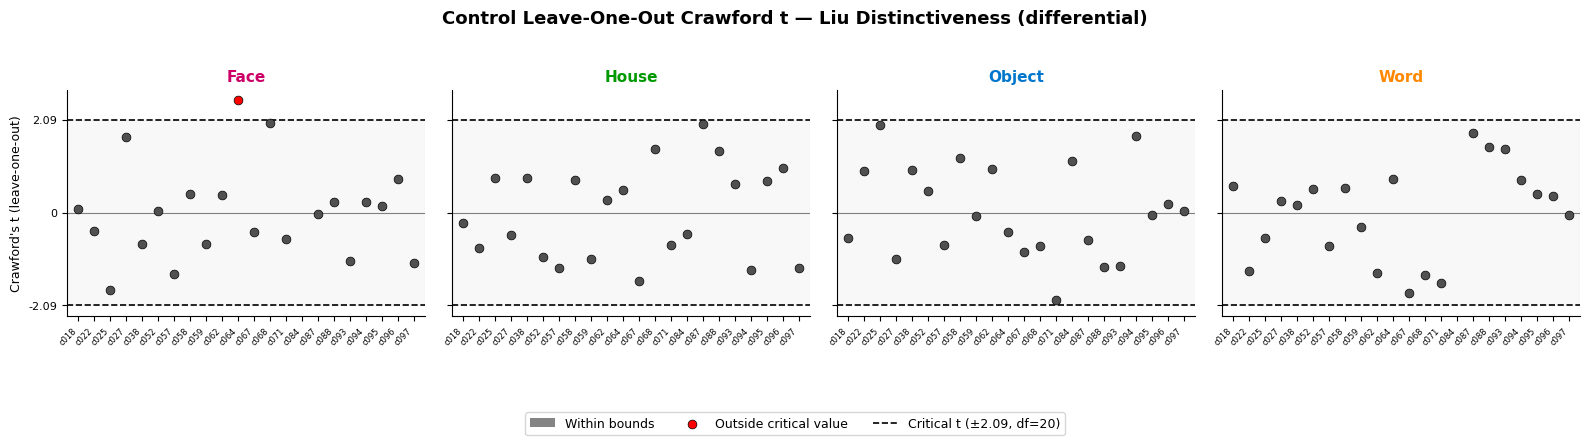

  Saved: fig_crawford_controls_differential.png


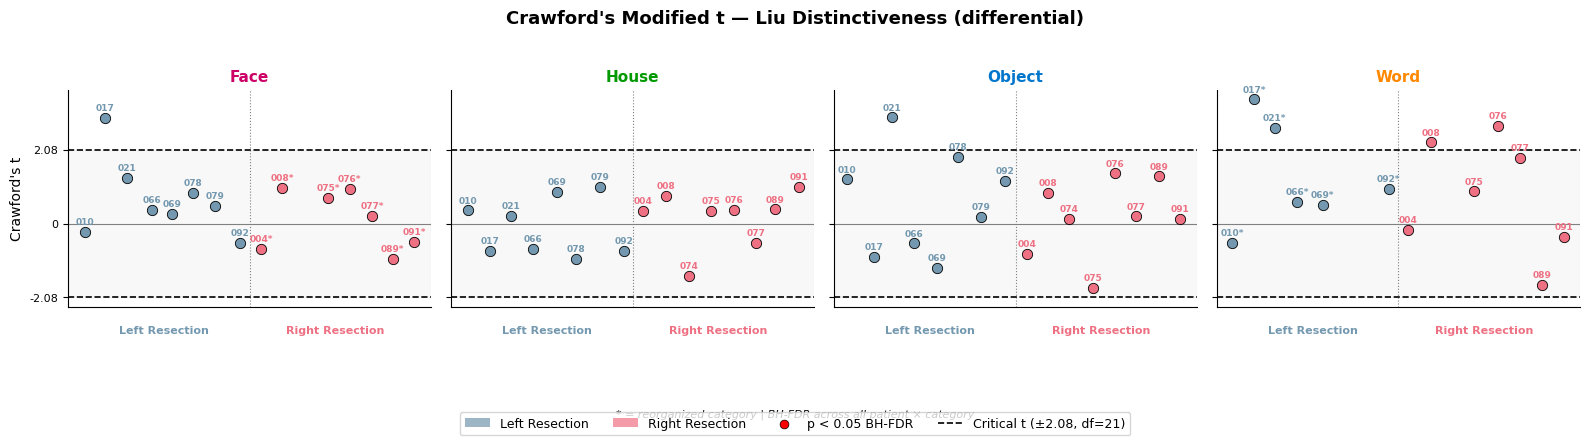

  Saved: fig_crawford_differential.png


In [8]:
# CELL 6: Crawford t-score figures — controls (LOO) and patients
# ═══════════════════════════════════════════════════════════════════════════════

def _compute_crawford_controls(ctrl):
    """Leave-one-out Crawford t for each control x category."""
    rows = []
    for cat in CATEGORIES:
        ref_hemi = PREFERRED_CTRL_HEMI[cat]
        cat_ctrl = ctrl[(ctrl['category'] == cat) &
                        (ctrl['hemi_label'] == ref_hemi)]
        all_vals = cat_ctrl['liu_distinctiveness'].values
        for _, row in cat_ctrl.iterrows():
            loo_vals = all_vals[all_vals != row['liu_distinctiveness']]
            t, p, _  = crawford_t(row['liu_distinctiveness'], loo_vals)
            rows.append({'subject': row['subject'], 'category': cat,
                         't': t, 'p': p})
    return pd.DataFrame(rows)


def fig_crawford_controls(cope_set=COPE_SET):
    """Leave-one-out Crawford t for each control, one panel per category."""
    ctrl, _ = load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf    = _compute_crawford_controls(ctrl)
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = sp_stats.t.ppf(0.975, df=n_ctrl - 2)

    ctrl_subs = sorted(cdf['subject'].unique(), key=short_name)
    sub_x     = {s: i + 1 for i, s in enumerate(ctrl_subs)}
    n_cats    = len(CATEGORIES)

    fig, axes = plt.subplots(1, n_cats, figsize=(4 * n_cats, 4), sharey=True)

    for col_idx, cat in enumerate(CATEGORIES):
        ax      = axes[col_idx]
        cat_cdf = cdf[cdf['category'] == cat]
        ax.axhline(0,        color='gray',  linewidth=0.8, zorder=1)
        ax.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhspan(-t_crit, t_crit, alpha=0.05, color='gray', zorder=0)

        for _, row in cat_cdf.iterrows():
            if np.isnan(row['t']):
                continue
            dot = 'red' if abs(row['t']) > t_crit else CTRL_R
            ax.scatter(sub_x[row['subject']], row['t'], color=dot,
                       s=40, zorder=4, edgecolors='black', linewidth=0.5)

        ax.set_xlim(0.3, len(ctrl_subs) + 0.7)
        ax.set_xticks(list(sub_x.values()))
        ax.set_xticklabels([short_name(s) for s in ctrl_subs],
                           fontsize=6, rotation=45, ha='right')
        ax.set_title(cat.title(), fontsize=11, fontweight='bold',
                     color=CAT_COLORS[cat])
        if col_idx == 0:
            ax.set_ylabel("Crawford's t (leave-one-out)", fontsize=9)
            ax.set_yticks([-t_crit, 0, t_crit])
            ax.set_yticklabels([f'{-t_crit:.2f}', '0', f'{t_crit:.2f}'], fontsize=8)

    fig.legend(handles=[
        Patch(facecolor=CTRL_R, alpha=0.7, label='Within bounds'),
        plt.scatter([], [], color='red', s=40, edgecolors='black',
                    linewidth=0.5, label='Outside critical value'),
        Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
               label=f'Critical t (\u00b1{t_crit:.2f}, df={n_ctrl-2})'),
    ], loc='lower center', ncol=3, fontsize=9, frameon=True,
       bbox_to_anchor=(0.5, -0.1))

    plt.suptitle(f'Control Leave-One-Out Crawford t \u2014 Liu Distinctiveness ({cope_set})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_crawford_controls_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_crawford_controls_{cope_set}.png')


def fig_crawford_distinctiveness(cope_set=COPE_SET):
    """Crawford t-scores for OTC patients, one panel per category."""
    ctrl, otc = load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf    = compute_crawford_rows(ctrl, otc)
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = sp_stats.t.ppf(0.975, df=n_ctrl - 1)
    n_cats = len(CATEGORIES)

    left_pts  = sorted(cdf[cdf['surgery_side'] == 'left']['subject'].unique(),
                       key=short_name)
    right_pts = sorted(cdf[cdf['surgery_side'] == 'right']['subject'].unique(),
                       key=short_name)
    all_pts   = left_pts + right_pts
    pt_x      = {sub: i + 1 for i, sub in enumerate(all_pts)}
    divider_x = len(left_pts) + 0.5

    fig, axes = plt.subplots(1, n_cats, figsize=(4 * n_cats, 4), sharey=True)

    for col_idx, cat in enumerate(CATEGORIES):
        ax      = axes[col_idx]
        cat_cdf = cdf[cdf['category'] == cat]
        ax.axhline(0,        color='gray',  linewidth=0.8, zorder=1)
        ax.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhspan(-t_crit, t_crit, alpha=0.05, color='gray', zorder=0)
        ax.axvline(divider_x, color='gray', linewidth=0.8, linestyle=':', zorder=1)

        for _, row in cat_cdf.iterrows():
            if np.isnan(row['t']):
                continue
            x    = pt_x[row['subject']] + RNG.uniform(-0.1, 0.1)
            base = OTC_L if row['surgery_side'] == 'left' else OTC_R
            dot  = 'red' if row['sig'] else base
            star = '*' if REORG.get(row['surgery_side']) == cat else ''
            ax.scatter(x, row['t'], color=dot, s=55, zorder=4,
                       edgecolors='black', linewidth=0.6)
            ax.annotate(f"{short_name(row['subject'])}{star}",
                        (x, row['t']), fontsize=6.5, fontweight='bold',
                        ha='center', va='bottom', xytext=(0, 4),
                        textcoords='offset points', color=dot)

        ax.set_xticks([])
        ax.set_xlim(0.3, len(all_pts) + 0.7)
        ax.set_title(cat.title(), fontsize=11, fontweight='bold',
                     color=CAT_COLORS[cat])
        if col_idx == 0:
            ax.set_ylabel("Crawford's t", fontsize=10)
            ax.set_yticks([-t_crit, 0, t_crit])
            ax.set_yticklabels([f'{-t_crit:.2f}', '0', f'{t_crit:.2f}'], fontsize=8)

        n_all = len(all_pts)
        ax.text((len(left_pts) / 2 + 0.5) / (n_all + 1), -0.12, 'Left Resection',
                ha='center', fontsize=8, color=OTC_L, fontweight='bold',
                transform=ax.transAxes, clip_on=False)
        ax.text((len(left_pts) + len(right_pts) / 2 + 0.5) / (n_all + 1), -0.12,
                'Right Resection', ha='center', fontsize=8, color=OTC_R,
                fontweight='bold', transform=ax.transAxes, clip_on=False)

    fig.legend(handles=[
        Patch(facecolor=OTC_L, alpha=0.7, label='Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.7, label='Right Resection'),
        plt.scatter([], [], color='red', s=40, edgecolors='black',
                    linewidth=0.5, label='p < 0.05 BH-FDR'),
        Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
               label=f'Critical t (\u00b1{t_crit:.2f}, df={n_ctrl-1})'),
    ], loc='lower center', ncol=4, fontsize=9, frameon=True,
       bbox_to_anchor=(0.5, -0.1))
    fig.text(0.5, -0.04, '* = reorganized category | BH-FDR across all patient \u00d7 category',
             ha='center', fontsize=8, style='italic')

    plt.suptitle(f"Crawford's Modified t \u2014 Liu Distinctiveness ({cope_set})",
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_crawford_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_crawford_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_crawford_controls(COPE_SET)
fig_crawford_distinctiveness(COPE_SET)

Mantel: nonOTC vs control: r=0.834, p=0.042
Mantel: OTC-left vs control: r=0.824, p=0.088
Mantel: OTC-right vs control: r=0.887, p=0.041


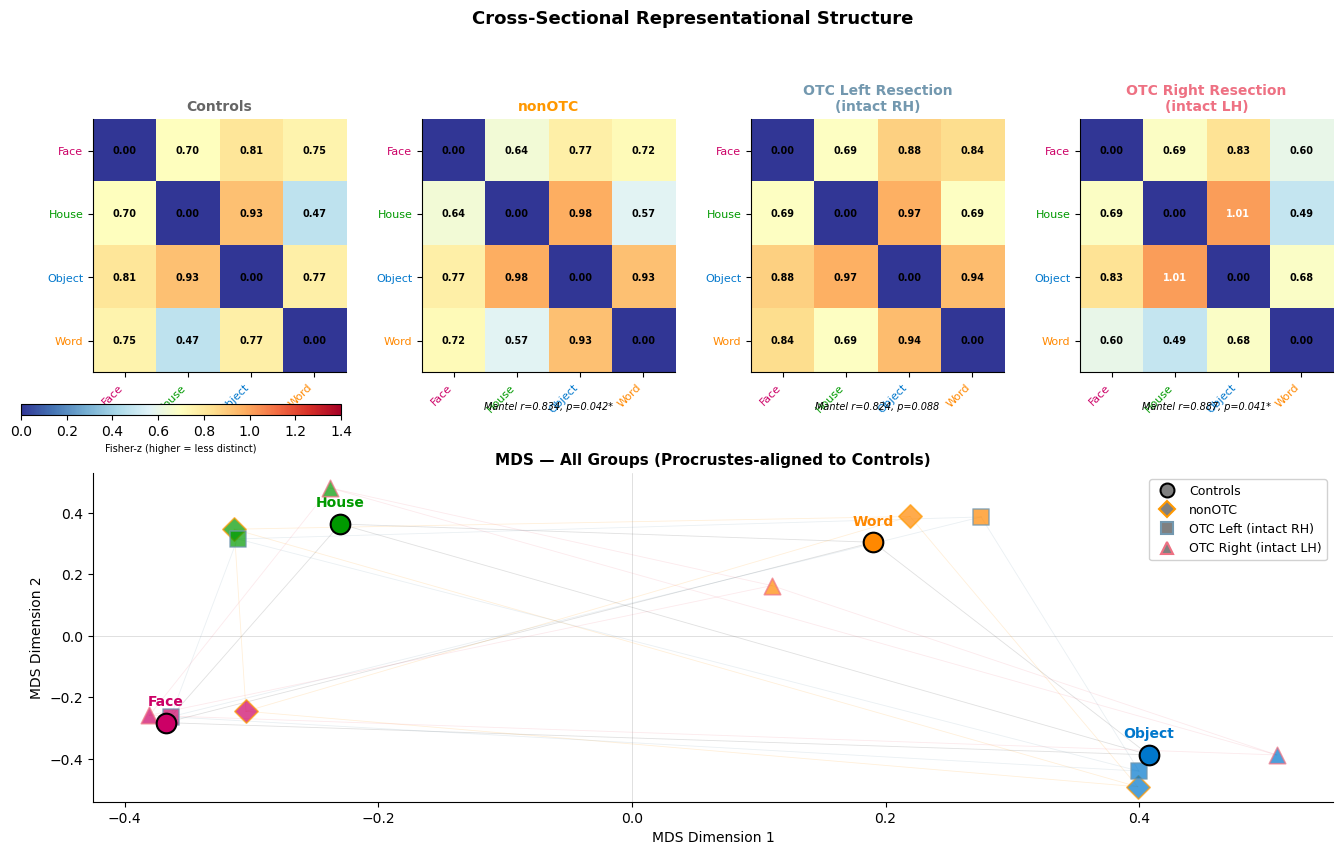

Saved: fig_rdm_mds_allgroups_differential.png
Loaded MDS shifts: 1316 rows
Columns: ['subject', 'subject_id', 'group', 'status', 'surgery_side', 'hemi', 'hemi_label', 'category', 'cat_type', 'roi_status', 'session_1', 'session_2', 'cope_set', 'measured_category', 'measured_cat_type', 'mds_shift']

OTC MDS rows: 76
Control MDS rows: 268
OTC subjects: ['sub-004', 'sub-008', 'sub-010', 'sub-021', 'sub-079']
ROIs (category): ['face', 'house', 'object', 'word']
Measured categories: ['face', 'house', 'object', 'word']


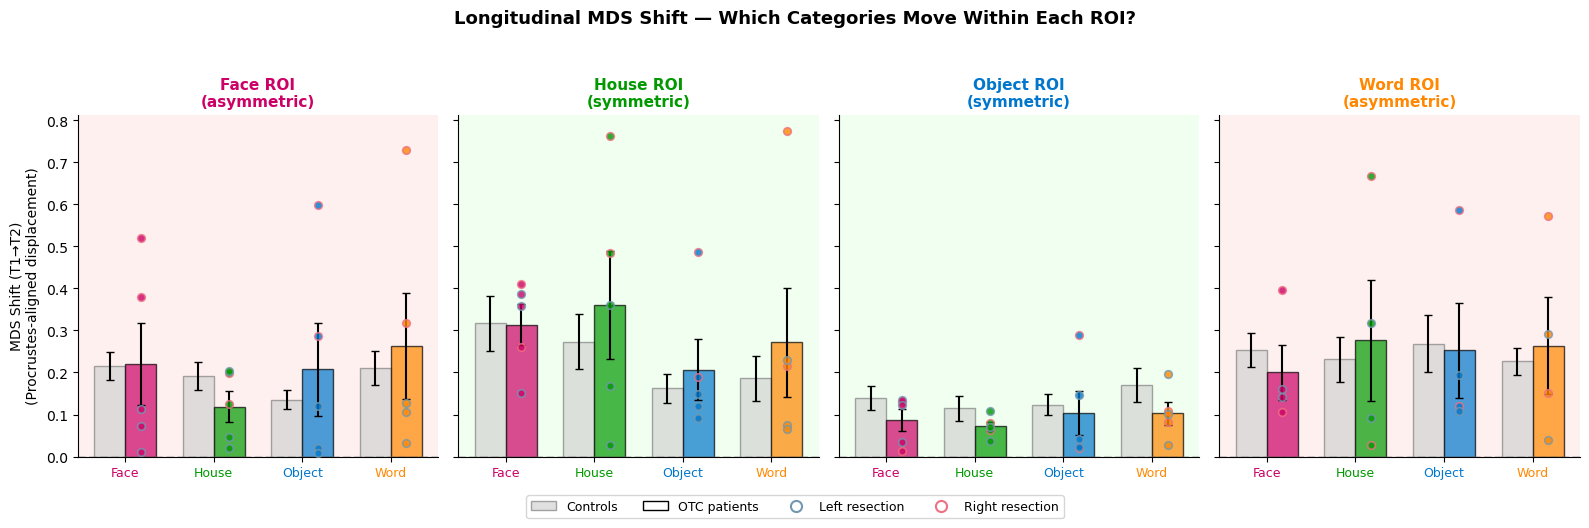

Saved: fig_mds_shift_per_roi_differential.png


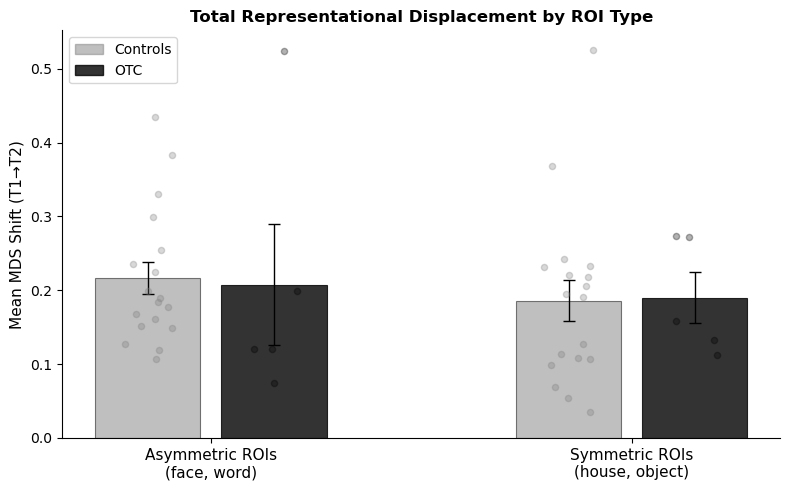

Saved: fig_mds_shift_summary_differential.png

MDS SHIFT SUMMARY

--- OTC ---

  face ROI:
    face shifted: M=0.2196, SD=0.2194, n=5
    house shifted: M=0.1186, SD=0.0839, n=5
    object shifted: M=0.2072, SD=0.2456, n=5
    word shifted: M=0.2627, SD=0.2808, n=5

  house ROI:
    face shifted: M=0.3141, SD=0.1074, n=5
    house shifted: M=0.3603, SD=0.2857, n=5
    object shifted: M=0.2069, SD=0.1607, n=5
    word shifted: M=0.2717, SD=0.2911, n=5

  object ROI:
    face shifted: M=0.0872, SD=0.0587, n=5
    house shifted: M=0.0719, SD=0.0254, n=5
    object shifted: M=0.1038, SD=0.1154, n=5
    word shifted: M=0.1035, SD=0.0613, n=5

  word ROI:
    face shifted: M=0.2007, SD=0.1316, n=4
    house shifted: M=0.2762, SD=0.2899, n=4
    object shifted: M=0.2524, SD=0.2258, n=4
    word shifted: M=0.2636, SD=0.2302, n=4

--- Control ---

  face ROI:
    face shifted: M=0.2157, SD=0.1405, n=18
    house shifted: M=0.1908, SD=0.1418, n=18
    object shifted: M=0.1355, SD=0.0976, n=18
  

In [9]:
# CELL A: Cross-Sectional Group RDM + Overlaid MDS
# ═══════════════════════════════════════════════════════════════════════════════
# Row of 4 RDMs: Controls | nonOTC | OTC-Left | OTC-Right
# Below: single MDS panel overlaying all groups (Procrustes-aligned to controls)
# Uses ALL ROIs (no unilateral/bilateral split)
# ═══════════════════════════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore')
from scipy.spatial import procrustes as scipy_procrustes
from sklearn.manifold import MDS as skMDS

pair_file = LIU_DIR / f'pairwise_correlations_{COPE_SET}.csv'
if not pair_file.exists():
    print(f'SKIP: {pair_file} not found')
else:
    df_pair = pd.read_csv(pair_file)

    # First session per subject
    first = (df_pair.groupby('subject_id')['session'].min()
                    .reset_index().rename(columns={'session': 'fs'}))
    df_pair = df_pair.merge(first, on='subject_id')
    df_pair = df_pair[df_pair['session'] == df_pair['fs']]

    # Keep only intact hemisphere for patients
    df_pair = df_pair[~((df_pair['group'].isin(['OTC', 'nonOTC'])) &
                        (df_pair['hemi_label'] != 'intact'))].copy()

    # Create plot groups
    def assign_plot_group(row):
        if row['group'] == 'control':
            return 'control'
        elif row['group'] == 'nonOTC':
            return 'nonOTC'
        elif row['group'] == 'OTC':
            return f"OTC-{row['surgery_side']}"
        return 'other'

    df_pair['plot_group'] = df_pair.apply(assign_plot_group, axis=1)

    cats  = CATEGORIES
    n_cat = len(cats)

    def get_mean_matrix(subset):
        mat = np.full((n_cat, n_cat), np.nan)
        for i, ci in enumerate(cats):
            for j, cj in enumerate(cats):
                if i == j:
                    mat[i, j] = 0.0
                    continue
                for pair_str in [f'{ci}-{cj}', f'{cj}-{ci}']:
                    v = subset[subset['pair'] == pair_str]['fisher_r'].values
                    if len(v) > 0:
                        mat[i, j] = v.mean()
                        break
        return mat

    def mantel_test(m1, m2, n_perm=9999):
        triu = np.triu_indices(n_cat, k=1)
        v1, v2 = m1[triu], m2[triu]
        mask = np.isfinite(v1) & np.isfinite(v2)
        v1, v2 = v1[mask], v2[mask]
        if len(v1) < 3:
            return np.nan, np.nan
        from scipy.stats import pearsonr
        r_obs, _ = pearsonr(v1, v2)
        count = 0
        idx = np.arange(n_cat)
        for _ in range(n_perm):
            perm = RNG.permutation(idx)
            m2_perm = m2[np.ix_(perm, perm)]
            r_perm, _ = pearsonr(v1, m2_perm[triu][mask])
            if r_perm >= r_obs:
                count += 1
        return r_obs, (count + 1) / (n_perm + 1)

    groups = [
        ('control',   'Controls',                '#666666'),
        ('nonOTC',    'nonOTC',                   NONOT),
        ('OTC-left',  'OTC Left Resection\n(intact RH)', OTC_L),
        ('OTC-right', 'OTC Right Resection\n(intact LH)', OTC_R),
    ]

    # Build matrices
    matrices = {}
    for grp_key, _, _ in groups:
        gd = df_pair[df_pair['plot_group'] == grp_key]
        if len(gd) > 0:
            matrices[grp_key] = get_mean_matrix(gd)

    # Mantel tests vs controls
    ctrl_mat = matrices.get('control')
    mantel_results = {}
    if ctrl_mat is not None:
        for grp_key in ['nonOTC', 'OTC-left', 'OTC-right']:
            if grp_key in matrices:
                r, p = mantel_test(ctrl_mat, matrices[grp_key])
                mantel_results[grp_key] = (r, p)
                print(f'Mantel: {grp_key} vs control: r={r:.3f}, p={p:.3f}')

    # MDS per group
    def compute_mds(mat):
        sim = mat.copy()
        np.fill_diagonal(sim, 0)
        col_means = np.nanmean(sim, axis=0)
        for i in range(n_cat):
            for j in range(n_cat):
                if np.isnan(sim[i, j]):
                    sim[i, j] = (col_means[i] + col_means[j]) / 2
        dissim = np.clip(sim, 0, None)
        dissim = (dissim + dissim.T) / 2
        np.fill_diagonal(dissim, 0)
        mds = skMDS(n_components=2, dissimilarity='precomputed',
                    random_state=42, n_init=20, normalized_stress='auto')
        return mds.fit_transform(dissim)

    mds_coords = {}
    for grp_key, mat in matrices.items():
        mds_coords[grp_key] = compute_mds(mat)

    # Procrustes-align all to controls
    ref = mds_coords.get('control')
    if ref is not None:
        for grp_key in mds_coords:
            if grp_key != 'control':
                _, aligned, _ = scipy_procrustes(ref, mds_coords[grp_key])
                mds_coords[grp_key] = aligned

    # ── Figure ────────────────────────────────────────────────────────────
    n_groups = len([g for g in groups if g[0] in matrices])
    fig = plt.figure(figsize=(4 * n_groups, 9))
    gs = fig.add_gridspec(2, n_groups, height_ratios=[1, 1.2],
                          hspace=0.3, wspace=0.3)

    tick_labels = [c.capitalize() for c in cats]

    # Top row: RDMs
    for col_idx, (grp_key, grp_label, grp_color) in enumerate(groups):
        if grp_key not in matrices:
            continue
        ax = fig.add_subplot(gs[0, col_idx])
        mat = matrices[grp_key]

        im = ax.imshow(mat, cmap='RdYlBu_r', vmin=0, vmax=1.4, aspect='equal')
        ax.set_xticks(range(n_cat))
        ax.set_xticklabels(tick_labels, fontsize=8, rotation=45, ha='right')
        ax.set_yticks(range(n_cat))
        ax.set_yticklabels(tick_labels, fontsize=8)
        ax.set_title(grp_label, fontsize=10, fontweight='bold', color=grp_color)

        for i, cat in enumerate(cats):
            ax.get_xticklabels()[i].set_color(CAT_COLORS[cat])
            ax.get_yticklabels()[i].set_color(CAT_COLORS[cat])

        for i in range(n_cat):
            for j in range(n_cat):
                if np.isnan(mat[i, j]):
                    continue
                txt_col = 'white' if mat[i, j] > 1.0 else 'black'
                ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                        fontsize=7, color=txt_col, fontweight='bold')

        if grp_key in mantel_results:
            r, p = mantel_results[grp_key]
            sig = '*' if p < 0.05 else ''
            ax.text(0.5, -0.15, f'Mantel r={r:.3f}, p={p:.3f}{sig}',
                    transform=ax.transAxes, ha='center', fontsize=7, style='italic')

    # Bottom: overlaid MDS
    ax_mds = fig.add_subplot(gs[1, :])

    group_markers = {
        'control':   'o',
        'nonOTC':    'D',
        'OTC-left':  's',
        'OTC-right': '^',
    }

    for grp_key, grp_label, grp_color in groups:
        if grp_key not in mds_coords:
            continue
        coords = mds_coords[grp_key]
        marker = group_markers.get(grp_key, 'o')
        is_ctrl = (grp_key == 'control')

        # Inter-category lines
        for i in range(n_cat):
            for j in range(i + 1, n_cat):
                ax_mds.plot([coords[i, 0], coords[j, 0]],
                            [coords[i, 1], coords[j, 1]],
                            color=grp_color, linewidth=0.6,
                            alpha=0.2 if is_ctrl else 0.15, zorder=1)

        for k, cat in enumerate(cats):
            ax_mds.scatter(coords[k, 0], coords[k, 1],
                           c=CAT_COLORS[cat],
                           s=200 if is_ctrl else 140,
                           alpha=1.0 if is_ctrl else 0.7,
                           edgecolors=grp_color if not is_ctrl else 'black',
                           linewidth=1.5 if is_ctrl else 1.2,
                           marker=marker, zorder=4 if is_ctrl else 3)

            if is_ctrl:
                ax_mds.annotate(cat.capitalize(),
                                (coords[k, 0], coords[k, 1]),
                                fontsize=10, fontweight='bold',
                                ha='center', va='bottom',
                                xytext=(0, 10), textcoords='offset points',
                                color=CAT_COLORS[cat])

    ax_mds.set_xlabel('MDS Dimension 1', fontsize=10)
    ax_mds.set_ylabel('MDS Dimension 2', fontsize=10)
    ax_mds.axhline(0, color='lightgray', linewidth=0.5, zorder=0)
    ax_mds.axvline(0, color='lightgray', linewidth=0.5, zorder=0)
    ax_mds.spines[['top', 'right']].set_visible(False)
    ax_mds.set_title('MDS — All Groups (Procrustes-aligned to Controls)',
                     fontsize=11, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
               markersize=10, markeredgecolor='black', markeredgewidth=1.5,
               label='Controls'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='grey',
               markersize=8, markeredgecolor=NONOT, markeredgewidth=1.5,
               label='nonOTC'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='grey',
               markersize=9, markeredgecolor=OTC_L, markeredgewidth=1.5,
               label='OTC Left (intact RH)'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='grey',
               markersize=9, markeredgecolor=OTC_R, markeredgewidth=1.5,
               label='OTC Right (intact LH)'),
    ]
    ax_mds.legend(handles=legend_elements, loc='best', fontsize=9, framealpha=0.9)

    # Colorbar
    cbar_ax = fig.add_axes([0.08, 0.54, 0.2, 0.012])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar_ax.set_xlabel('Fisher-z (higher = less distinct)', fontsize=7)

    fig.suptitle('Cross-Sectional Representational Structure',
                 fontsize=13, fontweight='bold', y=0.99)
    plt.savefig(str(FIG_DIR / f'fig_rdm_mds_allgroups_{COPE_SET}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: fig_rdm_mds_allgroups_{COPE_SET}.png')


# CELL B: Longitudinal T1→T2 MDS Shifts
# ═══════════════════════════════════════════════════════════════════════════════
# For each ROI, the geometry pipeline Procrustes-aligns the 4-category MDS
# embedding at T1 to T2, then measures per-category displacement.
#
# This tells us: within the house ROI, which categories shifted most in
# representational space between sessions? Is it house itself? Face/word
# encroaching? Everything moving uniformly?
#
# Key comparison: In symmetric ROIs, do symmetric measured_categories shift
# more than asymmetric ones (or vice versa)?
# ═══════════════════════════════════════════════════════════════════════════════

mds_file = GEO_DIR / f'mds_{COPE_SET}.csv'
if not mds_file.exists():
    print(f'SKIP: {mds_file} not found')
else:
    mds_df = pd.read_csv(mds_file)
    print(f'Loaded MDS shifts: {len(mds_df)} rows')
    print(f'Columns: {list(mds_df.columns)}')

    # Filter to canonical 4 ROIs and 4 measured categories
    mds_df = mds_df[mds_df['category'].isin(CATEGORIES) &
                    mds_df['measured_category'].isin(CATEGORIES)].copy()

    # Exclude OTC017
    mds_df = mds_df[~mds_df['subject'].str.contains('017', na=False)]

    otc_mds  = mds_df[mds_df['group'] == 'OTC'].copy()
    ctrl_mds = mds_df[mds_df['group'] == 'control'].copy()

    print(f'\nOTC MDS rows: {len(otc_mds)}')
    print(f'Control MDS rows: {len(ctrl_mds)}')
    print(f'OTC subjects: {sorted(otc_mds["subject_id"].unique())}')
    print(f'ROIs (category): {sorted(otc_mds["category"].unique())}')
    print(f'Measured categories: {sorted(otc_mds["measured_category"].unique())}')

    if otc_mds.empty:
        print('No OTC MDS data available.')
    else:
        # ── Panel 1: Per-ROI breakdown ────────────────────────────────────
        # For each ROI, show how much each measured category shifted,
        # OTC vs controls

        fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

        for roi_idx, roi_cat in enumerate(CATEGORIES):
            ax = axes[roi_idx]
            roi_type = 'symmetric' if roi_cat in BILATERAL else 'asymmetric'

            # Background tint
            bg = '#f0fff0' if roi_type == 'symmetric' else '#fff0f0'
            ax.set_facecolor(bg)

            # Control data for this ROI
            ctrl_roi = ctrl_mds[ctrl_mds['category'] == roi_cat]
            otc_roi  = otc_mds[otc_mds['category'] == roi_cat]

            x_pos = np.arange(len(CATEGORIES))
            width = 0.35

            # Control means + error bars
            ctrl_means = []
            ctrl_sems  = []
            otc_means  = []
            otc_sems   = []

            for mcat in CATEGORIES:
                cv = ctrl_roi[ctrl_roi['measured_category'] == mcat]['mds_shift'].dropna()
                ov = otc_roi[otc_roi['measured_category'] == mcat]['mds_shift'].dropna()
                ctrl_means.append(cv.mean() if len(cv) > 0 else 0)
                ctrl_sems.append(cv.sem() if len(cv) > 1 else 0)
                otc_means.append(ov.mean() if len(ov) > 0 else 0)
                otc_sems.append(ov.sem() if len(ov) > 1 else 0)

            bars_ctrl = ax.bar(x_pos - width/2, ctrl_means, width,
                               yerr=ctrl_sems, capsize=3,
                               color='lightgrey', edgecolor='grey',
                               label='Controls', alpha=0.7)
            bars_otc  = ax.bar(x_pos + width/2, otc_means, width,
                               yerr=otc_sems, capsize=3,
                               color=[CAT_COLORS[mc] for mc in CATEGORIES],
                               edgecolor='black', label='OTC', alpha=0.7)

            # Individual OTC patient points
            for mcat_idx, mcat in enumerate(CATEGORIES):
                ov = otc_roi[otc_roi['measured_category'] == mcat]
                for _, row in ov.iterrows():
                    side = str(row.get('surgery_side', ''))
                    ec = OTC_L if 'left' in side.lower() else OTC_R
                    ax.scatter(mcat_idx + width/2,
                               row['mds_shift'],
                               c=CAT_COLORS[mcat], edgecolors=ec,
                               linewidth=1.2, s=30, zorder=5, alpha=0.8)

            ax.set_xticks(x_pos)
            ax.set_xticklabels([c.capitalize() for c in CATEGORIES], fontsize=9)
            for i, cat in enumerate(CATEGORIES):
                ax.get_xticklabels()[i].set_color(CAT_COLORS[cat])

            ax.set_title(f'{roi_cat.capitalize()} ROI\n({roi_type})',
                         fontsize=11, fontweight='bold',
                         color=CAT_COLORS[roi_cat])
            ax.axhline(0, ls='--', color='grey', alpha=0.3)

            if roi_idx == 0:
                ax.set_ylabel('MDS Shift (T1→T2)\n(Procrustes-aligned displacement)',
                              fontsize=10)

        # Legend
        legend_elements = [
            Patch(facecolor='lightgrey', edgecolor='grey', alpha=0.7,
                  label='Controls'),
            Patch(facecolor='white', edgecolor='black',
                  label='OTC patients'),
            Line2D([0], [0], marker='o', color='w', markeredgecolor=OTC_L,
                   markerfacecolor='white', markersize=8, markeredgewidth=1.5,
                   label='Left resection'),
            Line2D([0], [0], marker='o', color='w', markeredgecolor=OTC_R,
                   markerfacecolor='white', markersize=8, markeredgewidth=1.5,
                   label='Right resection'),
        ]
        fig.legend(handles=legend_elements, loc='lower center', ncol=4,
                   fontsize=9, bbox_to_anchor=(0.5, -0.02))

        fig.suptitle('Longitudinal MDS Shift — Which Categories Move Within Each ROI?',
                     fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout(rect=[0, 0.04, 1, 0.97])
        plt.savefig(FIG_DIR / f'fig_mds_shift_per_roi_{COPE_SET}.png',
                    dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved: fig_mds_shift_per_roi_{COPE_SET}.png')

        # ── Panel 2: Summary — symmetric vs asymmetric ROIs ──────────────
        # Collapse across ROIs within each type, show total MDS shift

        fig2, ax2 = plt.subplots(1, 1, figsize=(8, 5))

        for status_label, status_df, x_offset, color, alpha in [
            ('Controls', ctrl_mds, -0.15, 'grey', 0.5),
            ('OTC',      otc_mds,   0.15, 'black', 0.8),
        ]:
            for cat_type_idx, (cat_type_label, roi_list) in enumerate([
                ('Asymmetric ROIs\n(face, word)', UNILATERAL),
                ('Symmetric ROIs\n(house, object)', BILATERAL),
            ]):
                subset = status_df[status_df['category'].isin(roi_list)]
                vals = subset.groupby(['subject_id', 'hemi'])['mds_shift'].mean()

                x = cat_type_idx + x_offset
                ax2.bar(x, vals.mean(), 0.25, color=color, alpha=alpha,
                        edgecolor='black', linewidth=0.8)
                ax2.errorbar(x, vals.mean(), yerr=vals.sem(), color='black',
                             capsize=4, linewidth=1)

                # Individual points
                for v in vals.values:
                    ax2.scatter(x + RNG.uniform(-0.06, 0.06), v,
                                c=color, alpha=0.3, s=20, zorder=5)

        ax2.set_xticks([0, 1])
        ax2.set_xticklabels(['Asymmetric ROIs\n(face, word)',
                              'Symmetric ROIs\n(house, object)'], fontsize=11)
        ax2.set_ylabel('Mean MDS Shift (T1→T2)', fontsize=11)
        ax2.set_title('Total Representational Displacement by ROI Type',
                      fontsize=12, fontweight='bold')
        ax2.legend([Patch(color='grey', alpha=0.5), Patch(color='black', alpha=0.8)],
                   ['Controls', 'OTC'], loc='upper left', fontsize=10)
        ax2.spines[['top', 'right']].set_visible(False)

        plt.tight_layout()
        plt.savefig(FIG_DIR / f'fig_mds_shift_summary_{COPE_SET}.png',
                    dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved: fig_mds_shift_summary_{COPE_SET}.png')

        # ── Print summary stats ──────────────────────────────────────────
        print('\n' + '='*70)
        print('MDS SHIFT SUMMARY')
        print('='*70)
        for status, sdf in [('OTC', otc_mds), ('Control', ctrl_mds)]:
            print(f'\n--- {status} ---')
            for roi_cat in CATEGORIES:
                roi_data = sdf[sdf['category'] == roi_cat]
                print(f'\n  {roi_cat} ROI:')
                for mcat in CATEGORIES:
                    vals = roi_data[roi_data['measured_category'] == mcat]['mds_shift']
                    if len(vals) > 0:
                        print(f'    {mcat} shifted: M={vals.mean():.4f}, '
                              f'SD={vals.std():.4f}, n={len(vals)}')

Mantel: nonOTC vs control: r=0.834, p=0.042
Mantel: OTC-left vs control: r=0.824, p=0.079
Mantel: OTC-right vs control: r=0.887, p=0.041


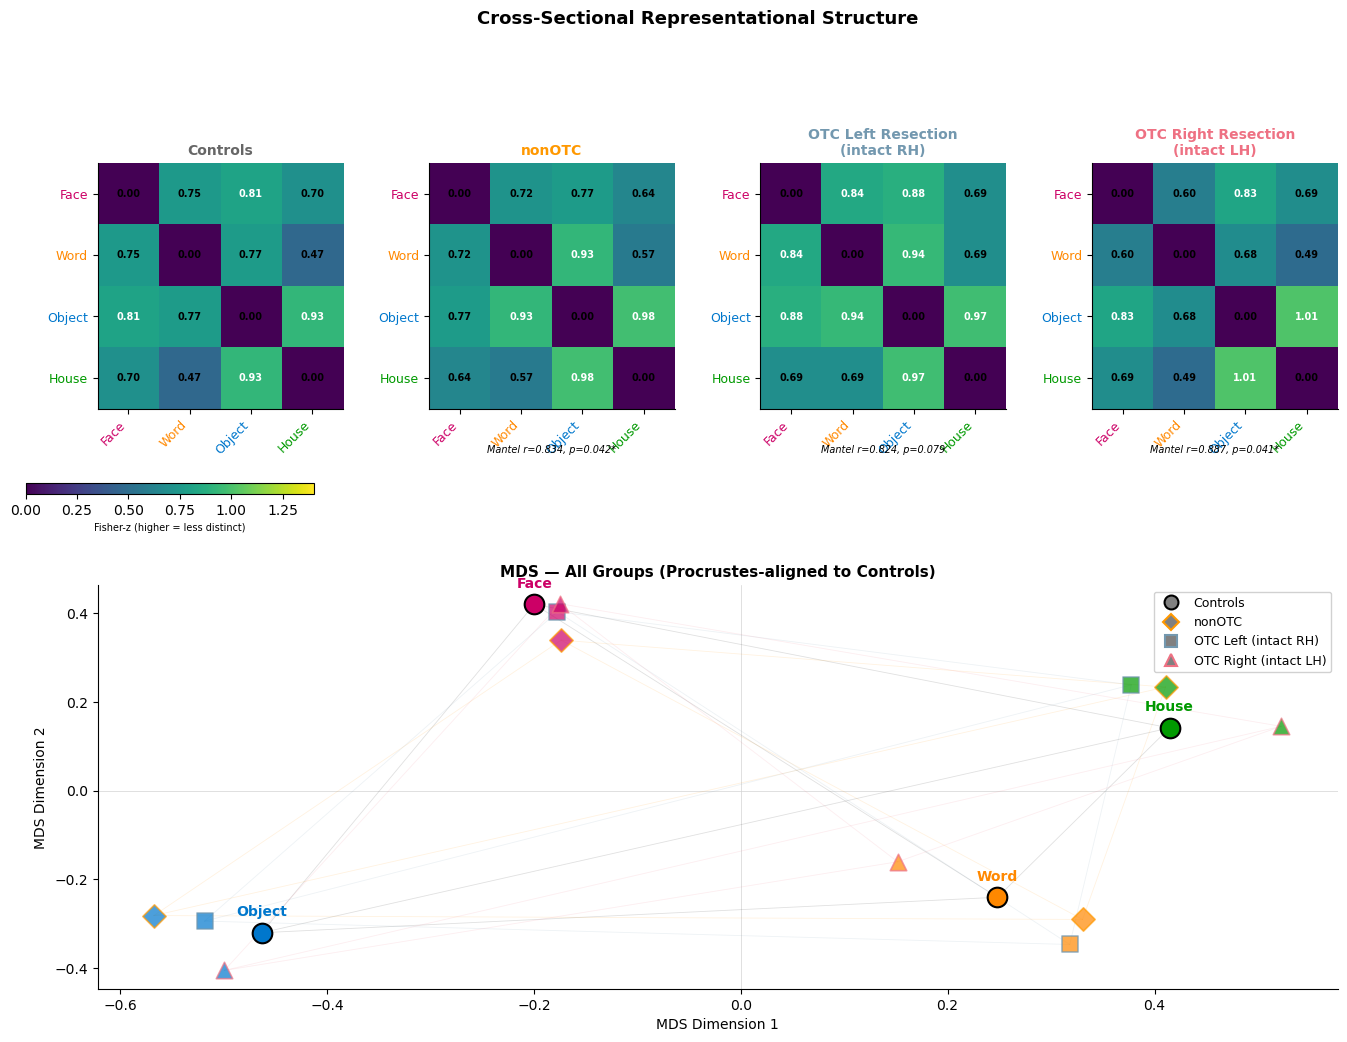

Saved: fig_rdm_mds_allgroups_differential.png
Loaded MDS shifts: 1316 rows
OTC-left MDS rows: 44, subjects: 3
OTC-right MDS rows: 32, subjects: 2
Control MDS rows: 268, subjects: 9


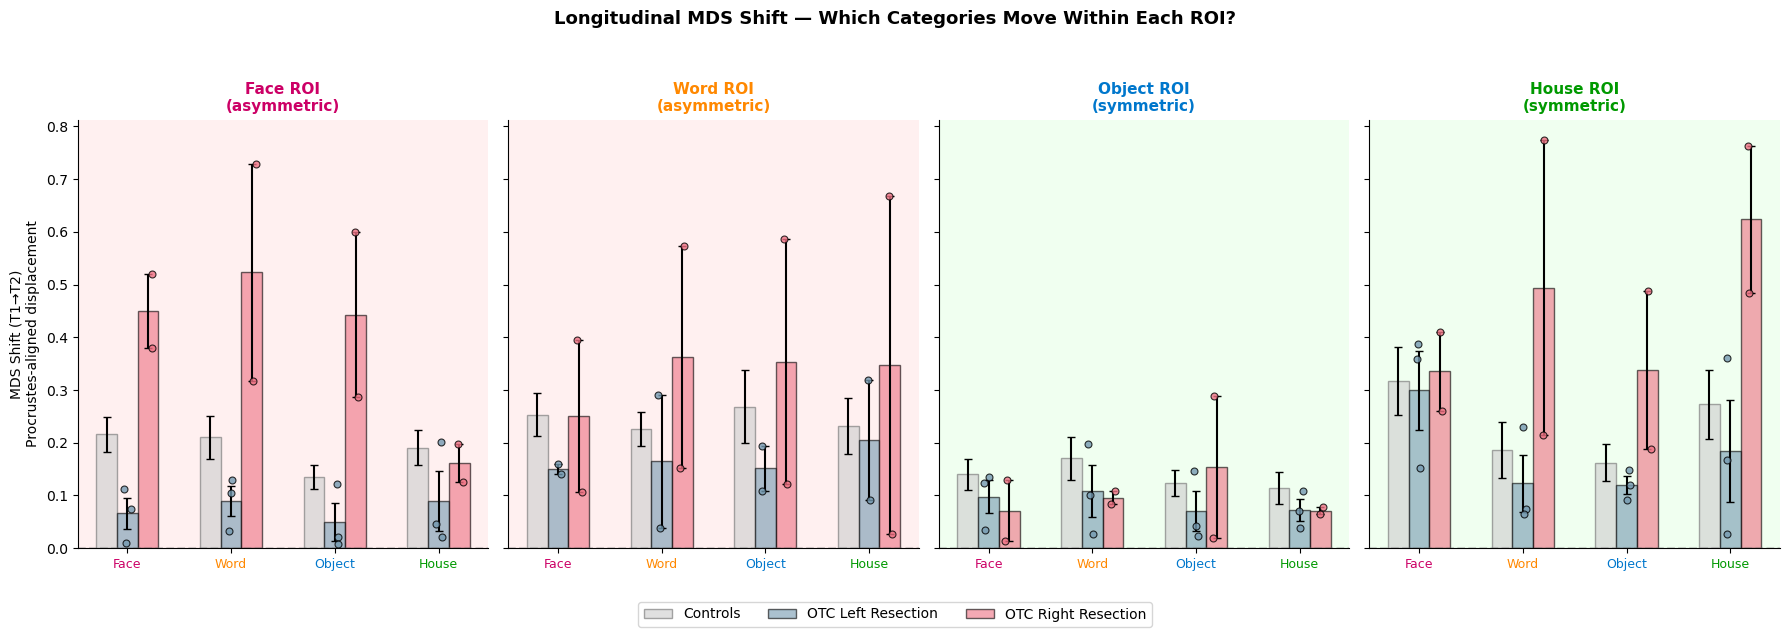

Saved: fig_mds_shift_per_roi_differential.png


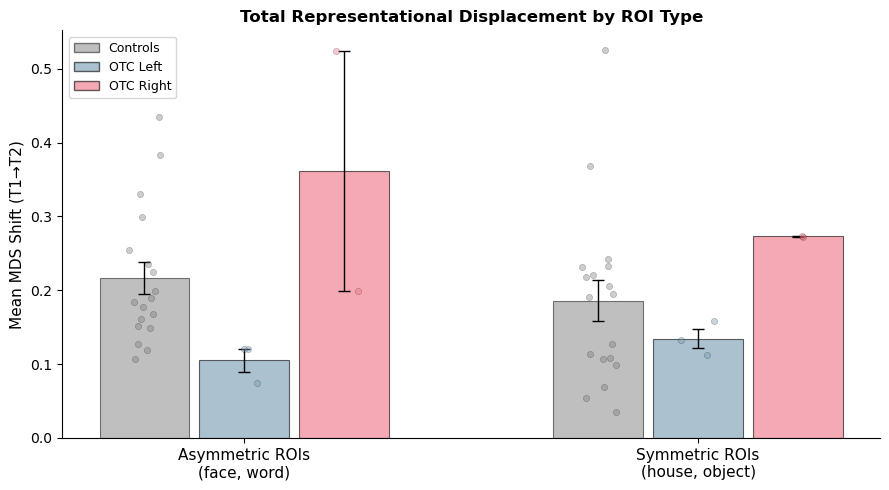

Saved: fig_mds_shift_summary_differential.png

MDS SHIFT SUMMARY (left/right OTC separated)

--- OTC-left ---
  face ROI:
    face: M=0.0659, SD=0.0516, n=3
    word: M=0.0891, SD=0.0497, n=3
    object: M=0.0501, SD=0.0616, n=3
    house: M=0.0898, SD=0.0982, n=3
  word ROI:
    face: M=0.1506, SD=0.0132, n=2
    word: M=0.1651, SD=0.1783, n=2
    object: M=0.1512, SD=0.0599, n=2
    house: M=0.2051, SD=0.1606, n=2
  object ROI:
    face: M=0.0979, SD=0.0554, n=3
    word: M=0.1086, SD=0.0852, n=3
    object: M=0.0703, SD=0.0665, n=3
    house: M=0.0722, SD=0.0352, n=3
  house ROI:
    face: M=0.2996, SD=0.1290, n=3
    word: M=0.1234, SD=0.0931, n=3
    object: M=0.1197, SD=0.0289, n=3
    house: M=0.1846, SD=0.1677, n=3

--- OTC-right ---
  face ROI:
    face: M=0.4502, SD=0.0998, n=2
    word: M=0.5230, SD=0.2908, n=2
    object: M=0.4427, SD=0.2208, n=2
    house: M=0.1618, SD=0.0513, n=2
  word ROI:
    face: M=0.2507, SD=0.2043, n=2
    word: M=0.3620, SD=0.2974, n=2
    object:

In [10]:
# CELL A: Cross-Sectional Group RDM + Overlaid MDS (FIXED)
# ═══════════════════════════════════════════════════════════════════════════════
# Fixes: viridis heatmap, face-word-object-house order, more vertical space,
#        nonOTC included, all ROIs combined
# ═══════════════════════════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore')
from scipy.spatial import procrustes as scipy_procrustes
from sklearn.manifold import MDS as skMDS

# Category order: face, word, object, house (asymmetric first, then symmetric)
CAT_ORDER = ['face', 'word', 'object', 'house']

pair_file = LIU_DIR / f'pairwise_correlations_{COPE_SET}.csv'
if not pair_file.exists():
    print(f'SKIP: {pair_file} not found')
else:
    df_pair = pd.read_csv(pair_file)

    # First session per subject
    first = (df_pair.groupby('subject_id')['session'].min()
                    .reset_index().rename(columns={'session': 'fs'}))
    df_pair = df_pair.merge(first, on='subject_id')
    df_pair = df_pair[df_pair['session'] == df_pair['fs']]

    # Keep only intact hemisphere for patients
    df_pair = df_pair[~((df_pair['group'].isin(['OTC', 'nonOTC'])) &
                        (df_pair['hemi_label'] != 'intact'))].copy()

    def assign_plot_group(row):
        if row['group'] == 'control':
            return 'control'
        elif row['group'] == 'nonOTC':
            return 'nonOTC'
        elif row['group'] == 'OTC':
            return f"OTC-{row['surgery_side']}"
        return 'other'

    df_pair['plot_group'] = df_pair.apply(assign_plot_group, axis=1)

    n_cat = len(CAT_ORDER)

    def get_mean_matrix(subset, cat_order=CAT_ORDER):
        mat = np.full((n_cat, n_cat), np.nan)
        for i, ci in enumerate(cat_order):
            for j, cj in enumerate(cat_order):
                if i == j:
                    mat[i, j] = 0.0
                    continue
                for pair_str in [f'{ci}-{cj}', f'{cj}-{ci}']:
                    v = subset[subset['pair'] == pair_str]['fisher_r'].values
                    if len(v) > 0:
                        mat[i, j] = v.mean()
                        break
        return mat

    def mantel_test(m1, m2, n_perm=9999):
        triu = np.triu_indices(n_cat, k=1)
        v1, v2 = m1[triu], m2[triu]
        mask = np.isfinite(v1) & np.isfinite(v2)
        v1, v2 = v1[mask], v2[mask]
        if len(v1) < 3:
            return np.nan, np.nan
        from scipy.stats import pearsonr
        r_obs, _ = pearsonr(v1, v2)
        count = 0
        idx = np.arange(n_cat)
        for _ in range(n_perm):
            perm = RNG.permutation(idx)
            m2_perm = m2[np.ix_(perm, perm)]
            r_perm, _ = pearsonr(v1, m2_perm[triu][mask])
            if r_perm >= r_obs:
                count += 1
        return r_obs, (count + 1) / (n_perm + 1)

    groups = [
        ('control',   'Controls',                     '#666666'),
        ('nonOTC',    'nonOTC',                        NONOT),
        ('OTC-left',  'OTC Left Resection\n(intact RH)', OTC_L),
        ('OTC-right', 'OTC Right Resection\n(intact LH)', OTC_R),
    ]

    matrices = {}
    for grp_key, _, _ in groups:
        gd = df_pair[df_pair['plot_group'] == grp_key]
        if len(gd) > 0:
            matrices[grp_key] = get_mean_matrix(gd)

    ctrl_mat = matrices.get('control')
    mantel_results = {}
    if ctrl_mat is not None:
        for grp_key in ['nonOTC', 'OTC-left', 'OTC-right']:
            if grp_key in matrices:
                r, p = mantel_test(ctrl_mat, matrices[grp_key])
                mantel_results[grp_key] = (r, p)
                print(f'Mantel: {grp_key} vs control: r={r:.3f}, p={p:.3f}')

    def compute_mds(mat):
        sim = mat.copy()
        np.fill_diagonal(sim, 0)
        col_means = np.nanmean(sim, axis=0)
        for i in range(n_cat):
            for j in range(n_cat):
                if np.isnan(sim[i, j]):
                    sim[i, j] = (col_means[i] + col_means[j]) / 2
        dissim = np.clip(sim, 0, None)
        dissim = (dissim + dissim.T) / 2
        np.fill_diagonal(dissim, 0)
        mds = skMDS(n_components=2, dissimilarity='precomputed',
                    random_state=42, n_init=20, normalized_stress='auto')
        return mds.fit_transform(dissim)

    mds_coords = {}
    for grp_key, mat in matrices.items():
        mds_coords[grp_key] = compute_mds(mat)

    ref = mds_coords.get('control')
    if ref is not None:
        for grp_key in mds_coords:
            if grp_key != 'control':
                _, aligned, _ = scipy_procrustes(ref, mds_coords[grp_key])
                mds_coords[grp_key] = aligned

    # ── Figure ────────────────────────────────────────────────────────────
    n_groups = len([g for g in groups if g[0] in matrices])

    fig = plt.figure(figsize=(4 * n_groups, 11))
    gs = fig.add_gridspec(2, n_groups, height_ratios=[1, 1.4],
                          hspace=0.45, wspace=0.35)

    tick_labels = [c.capitalize() for c in CAT_ORDER]

    # ── Top row: RDMs (viridis) ───────────────────────────────────────────
    for col_idx, (grp_key, grp_label, grp_color) in enumerate(groups):
        if grp_key not in matrices:
            continue
        ax = fig.add_subplot(gs[0, col_idx])
        mat = matrices[grp_key]

        im = ax.imshow(mat, cmap='viridis', vmin=0, vmax=1.4, aspect='equal')
        ax.set_xticks(range(n_cat))
        ax.set_xticklabels(tick_labels, fontsize=9, rotation=45, ha='right')
        ax.set_yticks(range(n_cat))
        ax.set_yticklabels(tick_labels, fontsize=9)
        ax.set_title(grp_label, fontsize=10, fontweight='bold', color=grp_color)

        for i, cat in enumerate(CAT_ORDER):
            ax.get_xticklabels()[i].set_color(CAT_COLORS[cat])
            ax.get_yticklabels()[i].set_color(CAT_COLORS[cat])

        for i in range(n_cat):
            for j in range(n_cat):
                if np.isnan(mat[i, j]):
                    continue
                txt_col = 'white' if mat[i, j] > 0.8 else 'black'
                ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                        fontsize=7, color=txt_col, fontweight='bold')

        if grp_key in mantel_results:
            r, p = mantel_results[grp_key]
            sig = '*' if p < 0.05 else ''
            ax.text(0.5, -0.18, f'Mantel r={r:.3f}, p={p:.3f}{sig}',
                    transform=ax.transAxes, ha='center', fontsize=7,
                    style='italic')

    # ── Bottom: overlaid MDS ──────────────────────────────────────────────
    ax_mds = fig.add_subplot(gs[1, :])

    group_markers = {
        'control':   'o',
        'nonOTC':    'D',
        'OTC-left':  's',
        'OTC-right': '^',
    }

    for grp_key, grp_label, grp_color in groups:
        if grp_key not in mds_coords:
            continue
        coords = mds_coords[grp_key]
        marker = group_markers.get(grp_key, 'o')
        is_ctrl = (grp_key == 'control')

        for i in range(n_cat):
            for j in range(i + 1, n_cat):
                ax_mds.plot([coords[i, 0], coords[j, 0]],
                            [coords[i, 1], coords[j, 1]],
                            color=grp_color, linewidth=0.6,
                            alpha=0.2 if is_ctrl else 0.12, zorder=1)

        for k, cat in enumerate(CAT_ORDER):
            ax_mds.scatter(coords[k, 0], coords[k, 1],
                           c=CAT_COLORS[cat],
                           s=200 if is_ctrl else 140,
                           alpha=1.0 if is_ctrl else 0.7,
                           edgecolors=grp_color if not is_ctrl else 'black',
                           linewidth=1.5 if is_ctrl else 1.2,
                           marker=marker, zorder=4 if is_ctrl else 3)

            if is_ctrl:
                ax_mds.annotate(cat.capitalize(),
                                (coords[k, 0], coords[k, 1]),
                                fontsize=10, fontweight='bold',
                                ha='center', va='bottom',
                                xytext=(0, 10), textcoords='offset points',
                                color=CAT_COLORS[cat])

    ax_mds.set_xlabel('MDS Dimension 1', fontsize=10)
    ax_mds.set_ylabel('MDS Dimension 2', fontsize=10)
    ax_mds.axhline(0, color='lightgray', linewidth=0.5, zorder=0)
    ax_mds.axvline(0, color='lightgray', linewidth=0.5, zorder=0)
    ax_mds.spines[['top', 'right']].set_visible(False)
    ax_mds.set_title('MDS — All Groups (Procrustes-aligned to Controls)',
                     fontsize=11, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
               markersize=10, markeredgecolor='black', markeredgewidth=1.5,
               label='Controls'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='grey',
               markersize=8, markeredgecolor=NONOT, markeredgewidth=1.5,
               label='nonOTC'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='grey',
               markersize=9, markeredgecolor=OTC_L, markeredgewidth=1.5,
               label='OTC Left (intact RH)'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='grey',
               markersize=9, markeredgecolor=OTC_R, markeredgewidth=1.5,
               label='OTC Right (intact LH)'),
    ]
    ax_mds.legend(handles=legend_elements, loc='best', fontsize=9, framealpha=0.9)

    cbar_ax = fig.add_axes([0.08, 0.56, 0.18, 0.01])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar_ax.set_xlabel('Fisher-z (higher = less distinct)', fontsize=7)

    fig.suptitle('Cross-Sectional Representational Structure',
                 fontsize=13, fontweight='bold', y=1.0)
    plt.savefig(str(FIG_DIR / f'fig_rdm_mds_allgroups_{COPE_SET}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: fig_rdm_mds_allgroups_{COPE_SET}.png')


# CELL B: Longitudinal T1→T2 MDS Shifts (FIXED)
# ═══════════════════════════════════════════════════════════════════════════════
# Fixes: separate left/right OTC, category order face-word-object-house,
#        more vertical space between panels
# ═══════════════════════════════════════════════════════════════════════════════

mds_file = GEO_DIR / f'mds_{COPE_SET}.csv'
if not mds_file.exists():
    print(f'SKIP: {mds_file} not found')
else:
    mds_df = pd.read_csv(mds_file)
    print(f'Loaded MDS shifts: {len(mds_df)} rows')

    # Filter to canonical 4 ROIs and 4 measured categories
    mds_df = mds_df[mds_df['category'].isin(CAT_ORDER) &
                    mds_df['measured_category'].isin(CAT_ORDER)].copy()
    mds_df = mds_df[~mds_df['subject'].str.contains('017', na=False)]

    # Separate groups: keep left/right OTC separate
    otc_l_mds = mds_df[(mds_df['group'] == 'OTC') &
                       (mds_df['surgery_side'] == 'left')].copy()
    otc_r_mds = mds_df[(mds_df['group'] == 'OTC') &
                       (mds_df['surgery_side'] == 'right')].copy()
    ctrl_mds  = mds_df[mds_df['group'] == 'control'].copy()

    print(f'OTC-left MDS rows: {len(otc_l_mds)}, subjects: {otc_l_mds["subject_id"].nunique()}')
    print(f'OTC-right MDS rows: {len(otc_r_mds)}, subjects: {otc_r_mds["subject_id"].nunique()}')
    print(f'Control MDS rows: {len(ctrl_mds)}, subjects: {ctrl_mds["subject_id"].nunique()}')

    if otc_l_mds.empty and otc_r_mds.empty:
        print('No OTC MDS data.')
    else:
        # ── Per-ROI breakdown ─────────────────────────────────────────────
        fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

        roi_order = CAT_ORDER  # face, word, object, house

        for roi_idx, roi_cat in enumerate(roi_order):
            ax = axes[roi_idx]
            roi_type = 'symmetric' if roi_cat in BILATERAL else 'asymmetric'
            bg = '#f0fff0' if roi_type == 'symmetric' else '#fff0f0'
            ax.set_facecolor(bg)

            x_pos = np.arange(len(CAT_ORDER))
            width = 0.2  # narrower to fit 3 groups

            # Control
            ctrl_roi = ctrl_mds[ctrl_mds['category'] == roi_cat]
            ctrl_means, ctrl_sems = [], []
            for mcat in CAT_ORDER:
                cv = ctrl_roi[ctrl_roi['measured_category'] == mcat]['mds_shift'].dropna()
                ctrl_means.append(cv.mean() if len(cv) > 0 else 0)
                ctrl_sems.append(cv.sem() if len(cv) > 1 else 0)

            # OTC-left
            otc_l_roi = otc_l_mds[otc_l_mds['category'] == roi_cat]
            otc_l_means, otc_l_sems = [], []
            for mcat in CAT_ORDER:
                ov = otc_l_roi[otc_l_roi['measured_category'] == mcat]['mds_shift'].dropna()
                otc_l_means.append(ov.mean() if len(ov) > 0 else 0)
                otc_l_sems.append(ov.sem() if len(ov) > 1 else 0)

            # OTC-right
            otc_r_roi = otc_r_mds[otc_r_mds['category'] == roi_cat]
            otc_r_means, otc_r_sems = [], []
            for mcat in CAT_ORDER:
                ov = otc_r_roi[otc_r_roi['measured_category'] == mcat]['mds_shift'].dropna()
                otc_r_means.append(ov.mean() if len(ov) > 0 else 0)
                otc_r_sems.append(ov.sem() if len(ov) > 1 else 0)

            # Bars
            ax.bar(x_pos - width, ctrl_means, width, yerr=ctrl_sems, capsize=3,
                   color='lightgrey', edgecolor='grey', label='Controls', alpha=0.7)
            ax.bar(x_pos, otc_l_means, width, yerr=otc_l_sems, capsize=3,
                   color=OTC_L, edgecolor='black', label='OTC Left', alpha=0.6)
            ax.bar(x_pos + width, otc_r_means, width, yerr=otc_r_sems, capsize=3,
                   color=OTC_R, edgecolor='black', label='OTC Right', alpha=0.6)

            # Individual patient dots — OTC left
            for mcat_idx, mcat in enumerate(CAT_ORDER):
                ov = otc_l_roi[otc_l_roi['measured_category'] == mcat]
                for _, row in ov.iterrows():
                    ax.scatter(mcat_idx + RNG.uniform(-0.04, 0.04),
                               row['mds_shift'],
                               c=OTC_L, edgecolors='black',
                               linewidth=0.8, s=25, zorder=5, alpha=0.8)

            # Individual patient dots — OTC right
            for mcat_idx, mcat in enumerate(CAT_ORDER):
                ov = otc_r_roi[otc_r_roi['measured_category'] == mcat]
                for _, row in ov.iterrows():
                    ax.scatter(mcat_idx + width + RNG.uniform(-0.04, 0.04),
                               row['mds_shift'],
                               c=OTC_R, edgecolors='black',
                               linewidth=0.8, s=25, zorder=5, alpha=0.8)

            ax.set_xticks(x_pos)
            ax.set_xticklabels([c.capitalize() for c in CAT_ORDER], fontsize=9)
            for i, cat in enumerate(CAT_ORDER):
                ax.get_xticklabels()[i].set_color(CAT_COLORS[cat])

            ax.set_title(f'{roi_cat.capitalize()} ROI\n({roi_type})',
                         fontsize=11, fontweight='bold',
                         color=CAT_COLORS[roi_cat])
            ax.axhline(0, ls='--', color='grey', alpha=0.3)

            if roi_idx == 0:
                ax.set_ylabel('MDS Shift (T1→T2)\nProcrustes-aligned displacement',
                              fontsize=10)

        legend_elements = [
            Patch(facecolor='lightgrey', edgecolor='grey', alpha=0.7,
                  label='Controls'),
            Patch(facecolor=OTC_L, edgecolor='black', alpha=0.6,
                  label='OTC Left Resection'),
            Patch(facecolor=OTC_R, edgecolor='black', alpha=0.6,
                  label='OTC Right Resection'),
        ]
        fig.legend(handles=legend_elements, loc='lower center', ncol=3,
                   fontsize=10, bbox_to_anchor=(0.5, -0.03))

        fig.suptitle('Longitudinal MDS Shift — Which Categories Move Within Each ROI?',
                     fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout(rect=[0, 0.05, 1, 0.97])
        plt.savefig(FIG_DIR / f'fig_mds_shift_per_roi_{COPE_SET}.png',
                    dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved: fig_mds_shift_per_roi_{COPE_SET}.png')

        # ── Summary by ROI type — separate left/right ─────────────────────
        fig2, ax2 = plt.subplots(1, 1, figsize=(9, 5))

        bar_groups = [
            ('Controls',        ctrl_mds,  'grey',   0.5),
            ('OTC Left\n(intact RH)',  otc_l_mds, OTC_L,   0.6),
            ('OTC Right\n(intact LH)', otc_r_mds, OTC_R,   0.6),
        ]

        n_bar_groups = len(bar_groups)
        width = 0.22
        offsets = np.linspace(-width, width, n_bar_groups)

        for grp_idx, (grp_label, grp_df, grp_color, grp_alpha) in enumerate(bar_groups):
            for cat_type_idx, (ct_label, roi_list) in enumerate([
                ('Asymmetric ROIs\n(face, word)', UNILATERAL),
                ('Symmetric ROIs\n(house, object)', BILATERAL),
            ]):
                subset = grp_df[grp_df['category'].isin(roi_list)]
                vals = subset.groupby(['subject_id', 'hemi'])['mds_shift'].mean()

                x = cat_type_idx + offsets[grp_idx]
                ax2.bar(x, vals.mean(), width * 0.9, color=grp_color,
                        alpha=grp_alpha, edgecolor='black', linewidth=0.8)
                if len(vals) > 1:
                    ax2.errorbar(x, vals.mean(), yerr=vals.sem(), color='black',
                                 capsize=4, linewidth=1)

                for v in vals.values:
                    ax2.scatter(x + RNG.uniform(-0.04, 0.04), v,
                                c=grp_color, alpha=0.4, s=20, zorder=5,
                                edgecolors='black', linewidth=0.3)

        ax2.set_xticks([0, 1])
        ax2.set_xticklabels(['Asymmetric ROIs\n(face, word)',
                              'Symmetric ROIs\n(house, object)'], fontsize=11)
        ax2.set_ylabel('Mean MDS Shift (T1→T2)', fontsize=11)
        ax2.set_title('Total Representational Displacement by ROI Type',
                      fontsize=12, fontweight='bold')

        legend_elements = [
            Patch(facecolor='grey', alpha=0.5, edgecolor='black', label='Controls'),
            Patch(facecolor=OTC_L, alpha=0.6, edgecolor='black', label='OTC Left'),
            Patch(facecolor=OTC_R, alpha=0.6, edgecolor='black', label='OTC Right'),
        ]
        ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
        ax2.spines[['top', 'right']].set_visible(False)

        plt.tight_layout()
        plt.savefig(FIG_DIR / f'fig_mds_shift_summary_{COPE_SET}.png',
                    dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved: fig_mds_shift_summary_{COPE_SET}.png')

        # ── Print summary ─────────────────────────────────────────────────
        print('\n' + '='*70)
        print('MDS SHIFT SUMMARY (left/right OTC separated)')
        print('='*70)
        for label, sdf in [('OTC-left', otc_l_mds),
                            ('OTC-right', otc_r_mds),
                            ('Control', ctrl_mds)]:
            print(f'\n--- {label} ---')
            for roi_cat in CAT_ORDER:
                roi_data = sdf[sdf['category'] == roi_cat]
                if roi_data.empty:
                    continue
                print(f'  {roi_cat} ROI:')
                for mcat in CAT_ORDER:
                    vals = roi_data[roi_data['measured_category'] == mcat]['mds_shift']
                    if len(vals) > 0:
                        print(f'    {mcat}: M={vals.mean():.4f}, SD={vals.std():.4f}, n={len(vals)}')

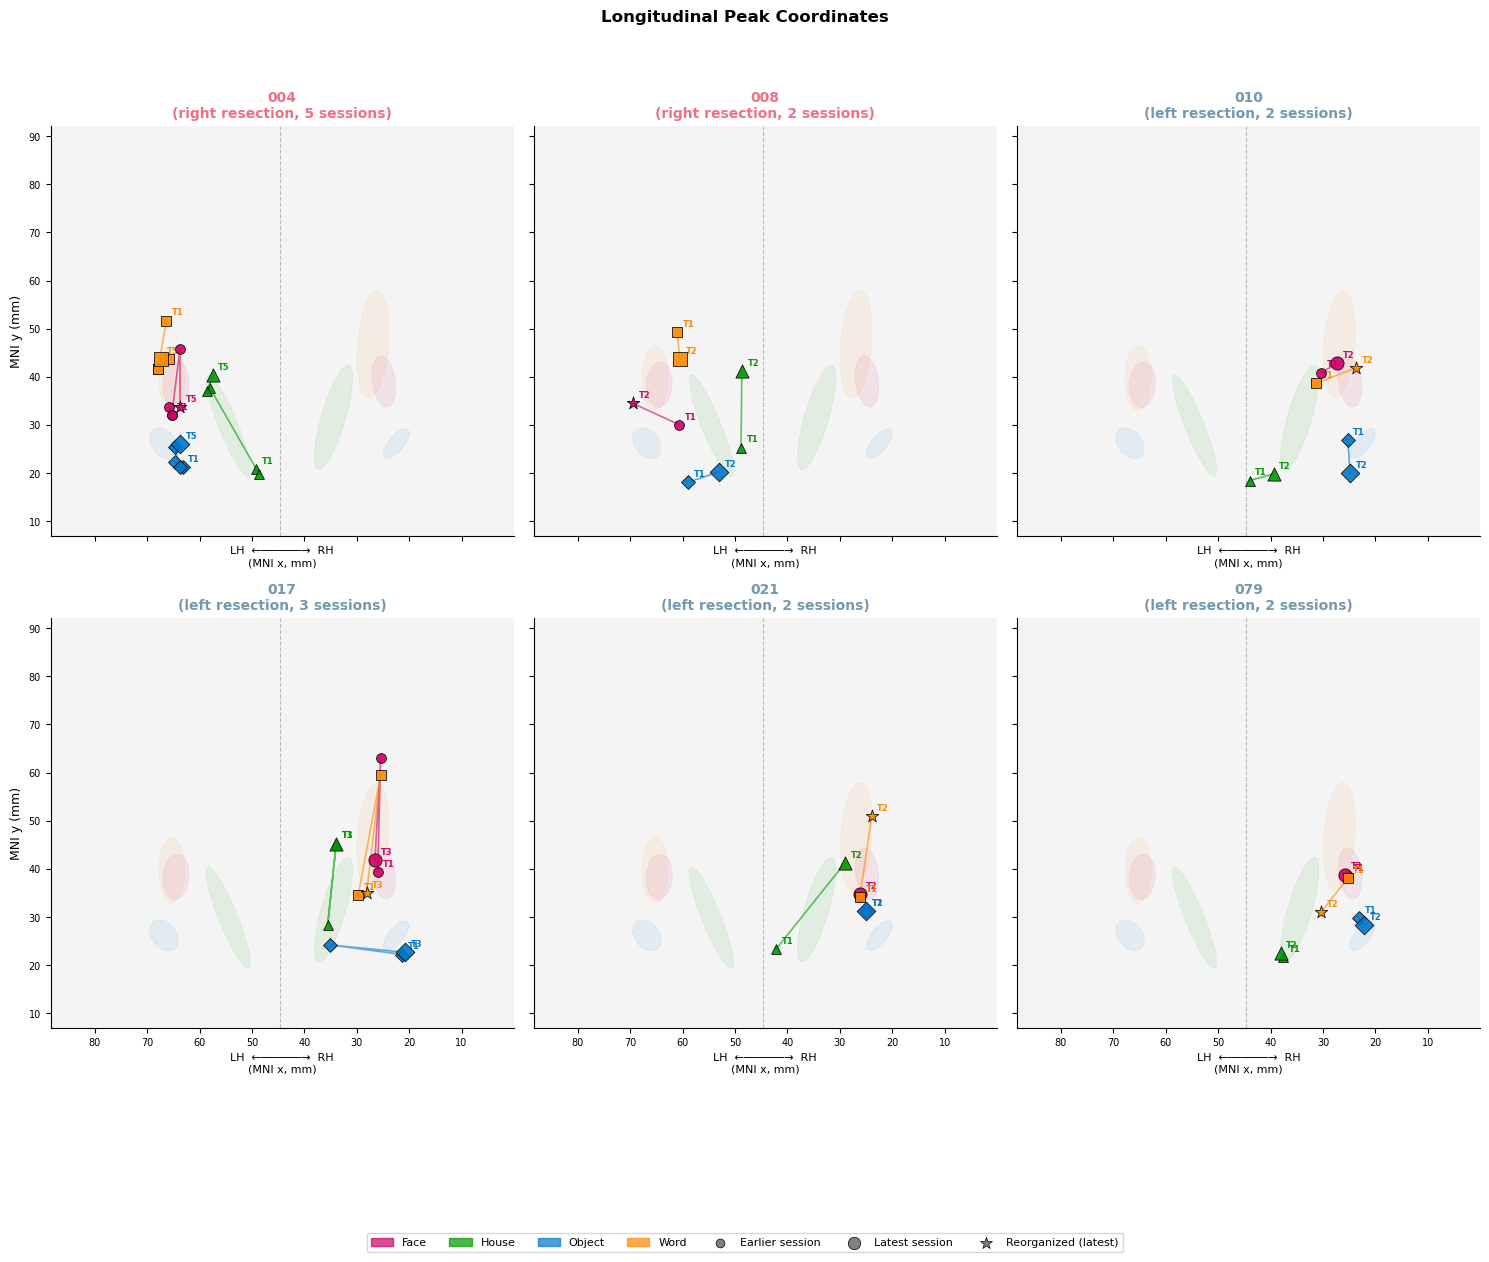

  Saved: fig_longitudinal_spatial.png


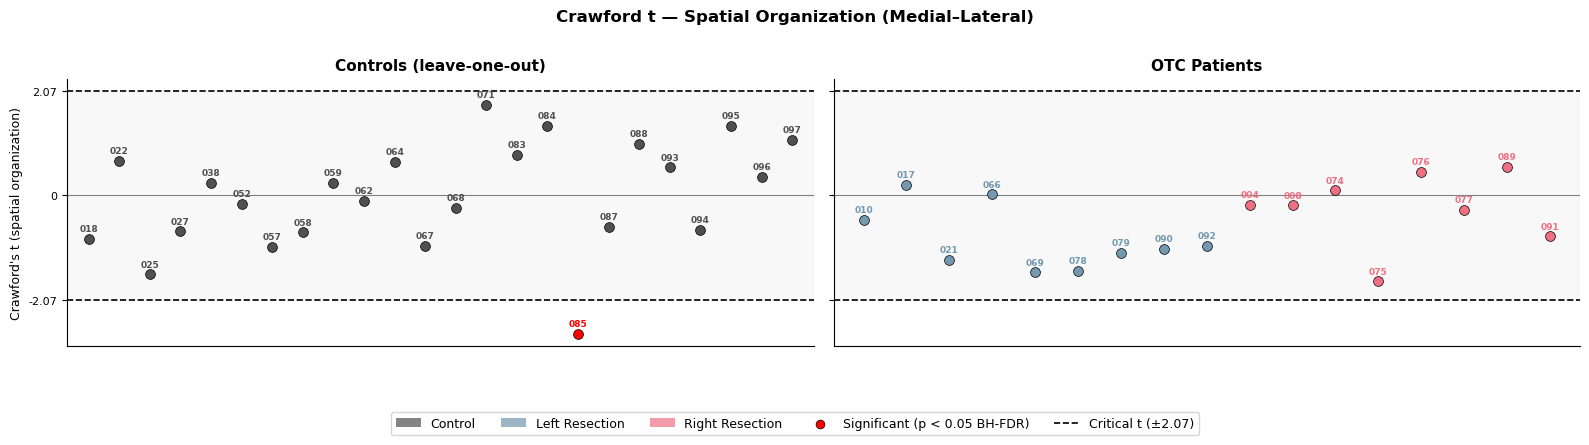

  Saved: fig_crawford_spatial.png


In [10]:

# CELL 8: Longitudinal Peak Coordinates + Crawford Spatial Organization
# ═══════════════════════════════════════════════════════════════════════════════

MIN_SESSIONS_LONG = 2


def fig_longitudinal_spatial(suffix=''):
    """One panel per longitudinal patient (>= 2 sessions): peak MNI coordinates
    per session, color-coded by category, connected across sessions."""

    pk_file = BASE / 'group_results' / 'peak_coords' / f'peak_coords{suffix}.csv'
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)

    otc = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    otc = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
              ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    n_ses    = otc.groupby('sub')['ses_int'].nunique()
    eligible = sorted(n_ses[n_ses >= MIN_SESSIONS_LONG].index.tolist())

    ctrl      = df[df['group'] == 'control'].copy()
    lx        = ctrl[ctrl['hemi'] == 'left']['peak_x_mni'].mean()
    rx        = ctrl[ctrl['hemi'] == 'right']['peak_x_mni'].mean()
    midline_x = (lx + rx) / 2

    pad  = 10
    xlim = (ctrl['peak_x_mni'].min() - pad, ctrl['peak_x_mni'].max() + pad)
    ylim = (ctrl['peak_y_mni'].min() - pad, ctrl['peak_y_mni'].max() + pad)

    n_pts = len(eligible)
    if n_pts == 0:
        print('  SKIP: no patients with >= 2 sessions')
        return
    n_cols = int(np.ceil(n_pts / 2))
    n_rows = min(2, n_pts)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 6 * n_rows),
                             sharey=True, sharex=True,
                             squeeze=False)
    fig.patch.set_facecolor('white')

    for idx, sub in enumerate(eligible):
        row_i = idx // n_cols
        col_i = idx % n_cols
        ax    = axes[row_i, col_i]
        ax.set_facecolor('#f4f4f4')
        sub_df = otc[otc['sub'] == sub].sort_values('ses_int')
        side   = sub_df['surgery_side'].iloc[0]
        col    = OTC_L if side == 'left' else OTC_R
        lbl    = short_name(sub)
        sessions = sorted(sub_df['ses_int'].unique())

        # Faint control ellipses as reference
        for cat in CATEGORIES:
            color = CAT_COLORS[cat]
            for hemi, ls in [('left', '--'), ('right', '-')]:
                hdat = ctrl[(ctrl['category'] == cat) &
                            (ctrl['hemi'] == hemi)].dropna(
                                subset=['peak_x_mni', 'peak_y_mni'])
                cx, cy = hdat['peak_x_mni'].values, hdat['peak_y_mni'].values
                if len(cx) >= 3:
                    confidence_ellipse(cx, cy, ax, n_std=1.0,
                                       facecolor=color, alpha=0.07,
                                       edgecolor=color, linewidth=0.8,
                                       linestyle=ls, zorder=1)

        # Per-category trajectories across sessions
        for cat in CATEGORIES:
            color  = CAT_COLORS[cat]
            cat_df = sub_df[sub_df['category'] == cat].sort_values('ses_int')
            xs     = cat_df['peak_x_mni'].values
            ys     = cat_df['peak_y_mni'].values
            ses_ids = cat_df['ses_int'].values

            if len(xs) < 1:
                continue
            if len(xs) > 1:
                ax.plot(xs, ys, color=color, linewidth=1.2, alpha=0.6, zorder=3)

            for i, (x, y, s) in enumerate(zip(xs, ys, ses_ids)):
                is_last = (i == len(xs) - 1)
                ax.scatter(x, y, color=color,
                           s=90 if is_last else 50,
                           marker='*' if (REORG.get(side) == cat and is_last)
                                      else CAT_MARKERS[cat],
                           edgecolors='black', linewidth=0.6,
                           alpha=0.9, zorder=4)
                if i == 0 or is_last:
                    ax.annotate(f'T{i+1}', (x, y), fontsize=6, color=color,
                                xytext=(4, 4), textcoords='offset points',
                                fontweight='bold')

        ax.axvline(midline_x, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.5)
        ax.set_xlim(xlim)
        ax.invert_xaxis()
        ax.set_ylim(ylim)
        ax.set_xlabel('LH  \u2190\u2500\u2500\u2500\u2500\u2500\u2500\u2192  RH\n(MNI x, mm)', fontsize=8)
        if col_i == 0:
            ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(f'{lbl}\n({side} resection, {len(sessions)} sessions)',
                     fontsize=10, fontweight='bold', color=col)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)

    # Hide empty axes if odd number of patients
    for idx in range(n_pts, n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    legend_cats  = [Patch(facecolor=CAT_COLORS[c], alpha=0.7,
                          edgecolor=CAT_COLORS[c],
                          label=c.title()) for c in CATEGORIES]
    legend_extra = [
        plt.scatter([], [], color='gray', marker='o', s=40,
                    edgecolors='black', linewidth=0.5, label='Earlier session'),
        plt.scatter([], [], color='gray', marker='o', s=80,
                    edgecolors='black', linewidth=0.5, label='Latest session'),
        plt.scatter([], [], color='gray', marker='*', s=80,
                    edgecolors='black', linewidth=0.5, label='Reorganized (latest)'),
    ]
    fig.legend(handles=legend_cats + legend_extra,
               loc='lower center', ncol=min(7, len(CATEGORIES) + 3),
               fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.06))

    suf_label = f' [{suffix[1:]}]' if suffix else ''
    plt.suptitle(f'Longitudinal Peak Coordinates{suf_label}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_longitudinal_spatial{suffix}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_longitudinal_spatial{suffix}.png')


def fig_crawford_spatial(suffix=''):
    """Crawford t-scores for spatial organization (medial-lateral x-coordinate
    correlation with control mean), controls (LOO) and patients."""

    pk_file = BASE / 'group_results' / 'peak_coords' / f'peak_coords{suffix}.csv'
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)
    first = (df.groupby('sub')['ses_int'].min()
               .reset_index().rename(columns={'ses_int': 'fs'}))
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()
    otc  = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
               ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    def spatial_corr(sub_df, ref_mean):
        sub_mean    = sub_df.groupby('category')['peak_x_mni'].mean()
        cats_shared = sorted(set(sub_mean.index) & set(ref_mean.index))
        if len(cats_shared) < 3:
            return np.nan
        r, _ = sp_stats.pearsonr(sub_mean.loc[cats_shared].values,
                                  ref_mean.loc[cats_shared].values)
        return float(r)

    ctrl_mean_x = ctrl.groupby('category')['peak_x_mni'].mean()

    def fz(r):
        return 0.5 * np.log((1 + np.clip(r, -0.999, 0.999)) /
                             (1 - np.clip(r, -0.999, 0.999)))

    # Controls: leave-one-out
    ctrl_subs  = sorted(ctrl['sub'].unique())
    ctrl_corrs = {}
    for sub in ctrl_subs:
        sub_df   = ctrl[ctrl['sub'] == sub]
        loo_mean = ctrl[ctrl['sub'] != sub].groupby('category')['peak_x_mni'].mean()
        r        = spatial_corr(sub_df, loo_mean)
        ctrl_corrs[sub] = fz(r) if not np.isnan(r) else np.nan

    ctrl_fz = np.array([v for v in ctrl_corrs.values() if not np.isnan(v)])
    n_ctrl  = len(ctrl_fz)
    t_crit  = sp_stats.t.ppf(0.975, df=n_ctrl - 2)

    ctrl_t = {}
    for sub in ctrl_subs:
        val = ctrl_corrs.get(sub, np.nan)
        if np.isnan(val):
            continue
        loo = np.array([v for s, v in ctrl_corrs.items()
                        if s != sub and not np.isnan(v)])
        t, _, _ = crawford_t(val, loo)
        ctrl_t[sub] = t

    # Patients
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    otc_subs  = sorted(otc['sub'].unique(),
                       key=lambda s: otc[otc['sub'] == s]['surgery_side'].iloc[0])
    otc_t, otc_sides = {}, {}
    for sub in otc_subs:
        sub_df = otc[otc['sub'] == sub]
        r      = spatial_corr(sub_df, ctrl_mean_x)
        fz_val = fz(r) if not np.isnan(r) else np.nan
        t, _, _ = (crawford_t(fz_val, ctrl_fz) if not np.isnan(fz_val)
                   else (np.nan, np.nan, 0))
        otc_t[sub]     = t
        otc_sides[sub] = sub_df['surgery_side'].iloc[0]

    pt_subs  = [s for s in otc_subs if not np.isnan(otc_t.get(s, np.nan))]
    pt_pvals = [2 * sp_stats.t.sf(abs(otc_t[s]), df=n_ctrl - 1) for s in pt_subs]
    pt_sig   = bh_fdr(np.array(pt_pvals)) if pt_pvals else []
    pt_sig_map = {s: sig for s, sig in zip(pt_subs, pt_sig)}

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

    for ax, (subs, t_dict, title, is_ctrl_panel) in zip(axes, [
        (ctrl_subs, ctrl_t, 'Controls (leave-one-out)', True),
        (otc_subs,  otc_t,  'OTC Patients',             False),
    ]):
        ax.axhline(0,        color='gray',  linewidth=0.8, zorder=1)
        ax.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhspan(-t_crit, t_crit, alpha=0.05, color='gray', zorder=0)

        for x_idx, sub in enumerate(subs):
            t = t_dict.get(sub, np.nan)
            if np.isnan(t):
                continue
            if is_ctrl_panel:
                col = CTRL_R
                dot = 'red' if abs(t) > t_crit else col
            else:
                side = otc_sides[sub]
                col  = OTC_L if side == 'left' else OTC_R
                dot  = 'red' if pt_sig_map.get(sub, False) else col

            ax.scatter(x_idx + 1, t, color=dot, s=50,
                       edgecolors='black', linewidth=0.5, zorder=4)
            ax.annotate(short_name(sub), (x_idx + 1, t),
                        fontsize=6.5, fontweight='bold',
                        ha='center', va='bottom', xytext=(0, 4),
                        textcoords='offset points', color=dot)

        ax.set_xlim(0.3, len(subs) + 0.7)
        ax.set_xticks([])
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

    axes[0].set_ylabel("Crawford's t (spatial organization)", fontsize=9)
    axes[0].set_yticks([-t_crit, 0, t_crit])
    axes[0].set_yticklabels([f'{-t_crit:.2f}', '0', f'{t_crit:.2f}'], fontsize=8)

    fig.legend(handles=[
        Patch(facecolor=CTRL_R, alpha=0.7, label='Control'),
        Patch(facecolor=OTC_L,  alpha=0.7, label='Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.7, label='Right Resection'),
        plt.scatter([], [], color='red', s=40, edgecolors='black',
                    linewidth=0.5, label='Significant (p < 0.05 BH-FDR)'),
        Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
               label=f'Critical t (\u00b1{t_crit:.2f})'),
    ], loc='lower center', ncol=5, fontsize=9, frameon=True,
       bbox_to_anchor=(0.5, -0.1))

    plt.suptitle('Crawford t \u2014 Spatial Organization (Medial\u2013Lateral)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.97])
    plt.savefig(str(FIG_DIR / f'fig_crawford_spatial{suffix}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_crawford_spatial{suffix}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_longitudinal_spatial()
fig_crawford_spatial()

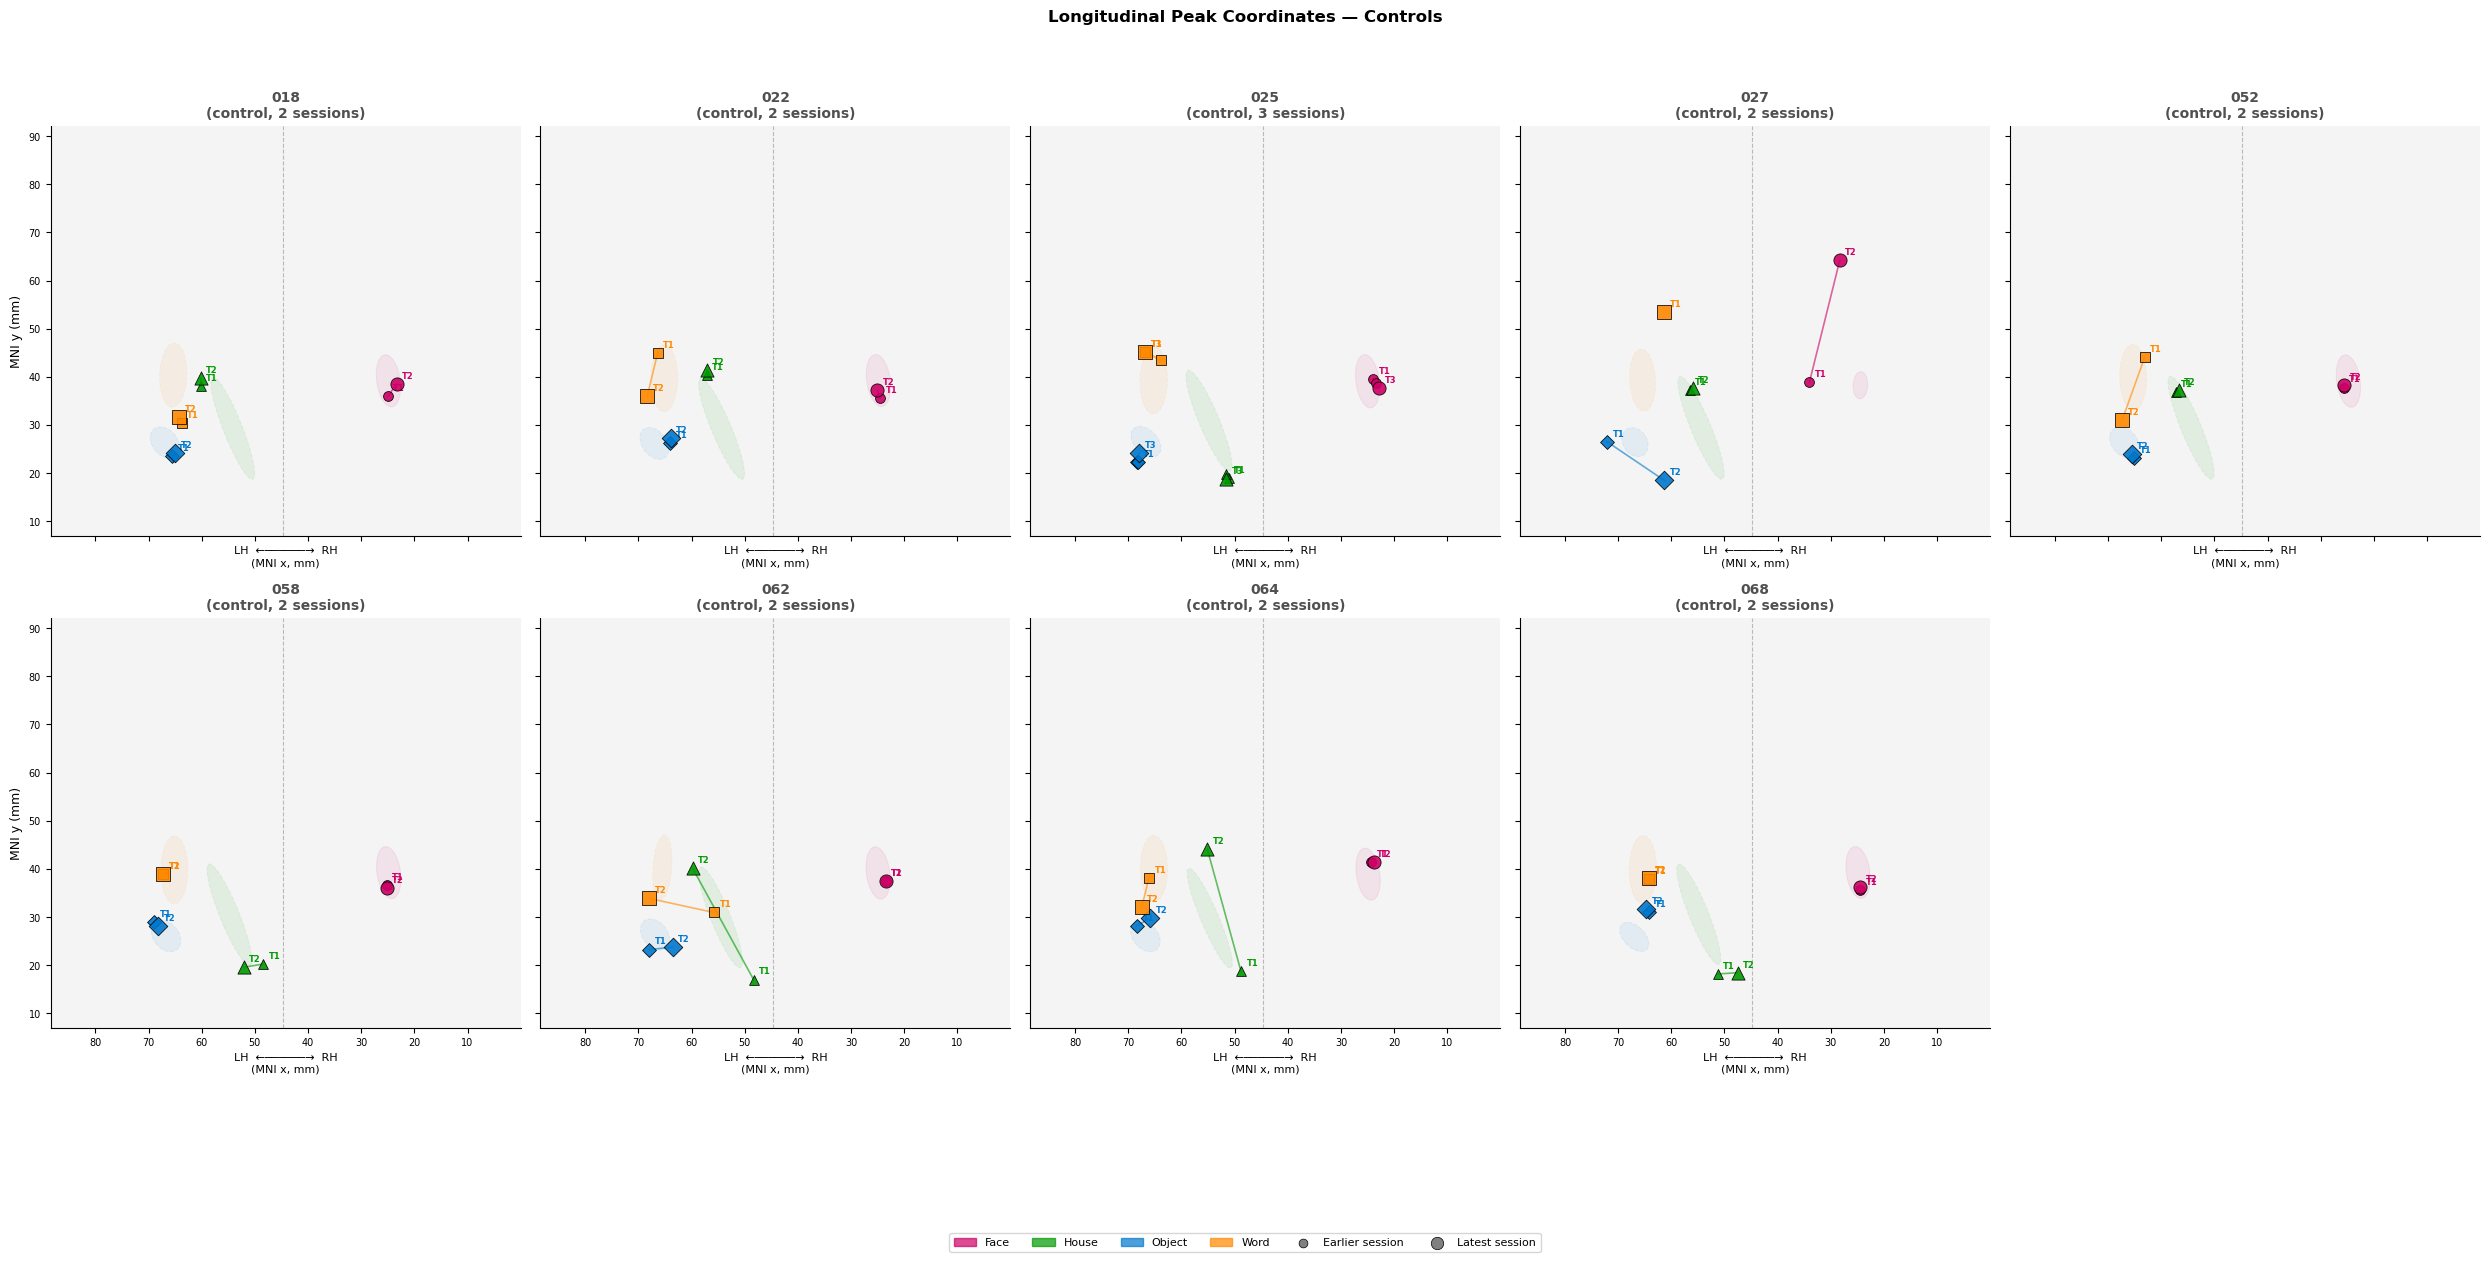

  Saved: fig_longitudinal_spatial_controls.png


In [11]:
# CELL 9: Longitudinal Peak Coordinates — Controls
# ═══════════════════════════════════════════════════════════════════════════════

def fig_longitudinal_spatial_controls(suffix=''):
    """One panel per longitudinal control (>= 2 sessions): peak MNI coordinates
    per session, color-coded by category, connected across sessions.
    Both hemispheres shown for each control."""

    pk_file = BASE / 'group_results' / 'peak_coords' / f'peak_coords{suffix}.csv'
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)

    ctrl = df[df['group'] == 'control'].copy()

    n_ses    = ctrl.groupby('sub')['ses_int'].nunique()
    eligible = sorted(n_ses[n_ses >= MIN_SESSIONS_LONG].index.tolist())

    if len(eligible) == 0:
        print('  SKIP: no controls with >= 2 sessions')
        return

    lx        = ctrl[ctrl['hemi'] == 'left']['peak_x_mni'].mean()
    rx        = ctrl[ctrl['hemi'] == 'right']['peak_x_mni'].mean()
    midline_x = (lx + rx) / 2

    pad  = 10
    xlim = (ctrl['peak_x_mni'].min() - pad, ctrl['peak_x_mni'].max() + pad)
    ylim = (ctrl['peak_y_mni'].min() - pad, ctrl['peak_y_mni'].max() + pad)

    n_pts = len(eligible)
    n_cols = int(np.ceil(n_pts / 2))
    n_rows = min(2, n_pts)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 6 * n_rows),
                             sharey=True, sharex=True,
                             squeeze=False)
    fig.patch.set_facecolor('white')

    for idx, sub in enumerate(eligible):
        row_i = idx // n_cols
        col_i = idx % n_cols
        ax    = axes[row_i, col_i]
        ax.set_facecolor('#f4f4f4')
        sub_df   = ctrl[ctrl['sub'] == sub].sort_values('ses_int')
        lbl      = short_name(sub)
        sessions = sorted(sub_df['ses_int'].unique())

        # Faint group ellipses as reference (preferred hemi only)
        for cat in CATEGORIES:
            color = CAT_COLORS[cat]
            pref  = PREFERRED_CTRL_HEMI[cat]
            ls    = '--' if pref == 'left' else '-'
            hdat  = ctrl[(ctrl['sub'] != sub) &
                         (ctrl['category'] == cat) &
                         (ctrl['hemi'] == pref)].dropna(
                             subset=['peak_x_mni', 'peak_y_mni'])
            cx, cy = hdat['peak_x_mni'].values, hdat['peak_y_mni'].values
            if len(cx) >= 3:
                confidence_ellipse(cx, cy, ax, n_std=1.0,
                                   facecolor=color, alpha=0.07,
                                   edgecolor=color, linewidth=0.8,
                                   linestyle=ls, zorder=1)

        # Per-category trajectories across sessions (preferred hemi only)
        for cat in CATEGORIES:
            color    = CAT_COLORS[cat]
            pref     = PREFERRED_CTRL_HEMI[cat]
            cat_df   = sub_df[(sub_df['category'] == cat) &
                              (sub_df['hemi'] == pref)].sort_values('ses_int')
            xs      = cat_df['peak_x_mni'].values
            ys      = cat_df['peak_y_mni'].values
            ses_ids = cat_df['ses_int'].values

            if len(xs) < 1:
                continue
            if len(xs) > 1:
                ax.plot(xs, ys, color=color, linewidth=1.2, alpha=0.6, zorder=3)

            for i, (x, y, s) in enumerate(zip(xs, ys, ses_ids)):
                is_last = (i == len(xs) - 1)
                ax.scatter(x, y, color=color,
                           s=90 if is_last else 50,
                           marker=CAT_MARKERS[cat],
                           edgecolors='black', linewidth=0.6,
                           alpha=0.9, zorder=4)
                if i == 0 or is_last:
                    ax.annotate(f'T{i+1}', (x, y), fontsize=6, color=color,
                                xytext=(4, 4), textcoords='offset points',
                                fontweight='bold')

        ax.axvline(midline_x, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.5)
        ax.set_xlim(xlim)
        ax.invert_xaxis()
        ax.set_ylim(ylim)
        ax.set_xlabel('LH  \u2190\u2500\u2500\u2500\u2500\u2500\u2500\u2192  RH\n(MNI x, mm)', fontsize=8)
        if col_i == 0:
            ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(f'{lbl}\n(control, {len(sessions)} sessions)',
                     fontsize=10, fontweight='bold', color=CTRL_R)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)

    # Hide empty axes
    for idx in range(n_pts, n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    legend_cats  = [Patch(facecolor=CAT_COLORS[c], alpha=0.7,
                          edgecolor=CAT_COLORS[c],
                          label=c.title()) for c in CATEGORIES]
    legend_extra = [
        plt.scatter([], [], color='gray', marker='o', s=40,
                    edgecolors='black', linewidth=0.5, label='Earlier session'),
        plt.scatter([], [], color='gray', marker='o', s=80,
                    edgecolors='black', linewidth=0.5, label='Latest session'),
    ]
    fig.legend(handles=legend_cats + legend_extra,
               loc='lower center', ncol=min(6, len(CATEGORIES) + 2),
               fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.06))

    suf_label = f' [{suffix[1:]}]' if suffix else ''
    plt.suptitle(f'Longitudinal Peak Coordinates \u2014 Controls{suf_label}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_longitudinal_spatial_controls{suffix}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_longitudinal_spatial_controls{suffix}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_longitudinal_spatial_controls()

Loaded split-half: 1247 rows


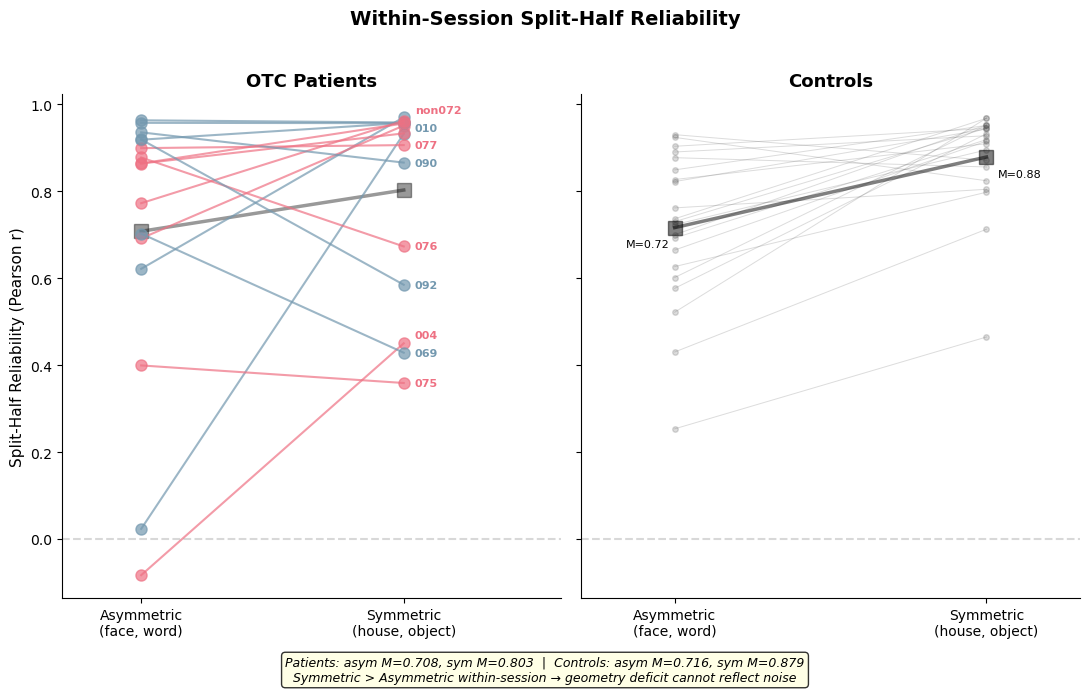

Saved: /user_data/csimmon2/sym_pt/group_results/figures/split_half_reliability.png
Loaded geometry: 329 rows

All categories in geometry CSV: ['evc', 'face', 'face_FFA', 'face_STS', 'house', 'house_PPA', 'house_TOS', 'object', 'object_LOC', 'object_pF', 'word', 'word_STG', 'word_VWFA']
All groups: ['OTC', 'control', 'nonOTC']

OTC rows (excl 017): 59
OTC categories: ['evc', 'face', 'face_FFA', 'face_STS', 'house', 'house_PPA', 'house_TOS', 'object', 'object_LOC', 'object_pF', 'word', 'word_STG', 'word_VWFA']
OTC subjects: ['sub-004', 'sub-008', 'sub-010', 'sub-021', 'sub-079']
  house_PPA: 5 OTC rows
  house_TOS: 5 OTC rows
  object_LOC: 5 OTC rows
  object_pF: 5 OTC rows

OTC sub-ROI rows: 20
Control sub-ROI rows: 72

Patients with sub-ROI data: 5
  OTC004: ['house_PPA', 'house_TOS', 'object_LOC', 'object_pF']
  OTC008: ['house_PPA', 'house_TOS', 'object_LOC', 'object_pF']
  OTC010: ['house_PPA', 'house_TOS', 'object_LOC', 'object_pF']
  OTC021: ['house_PPA', 'house_TOS', 'object_LOC'

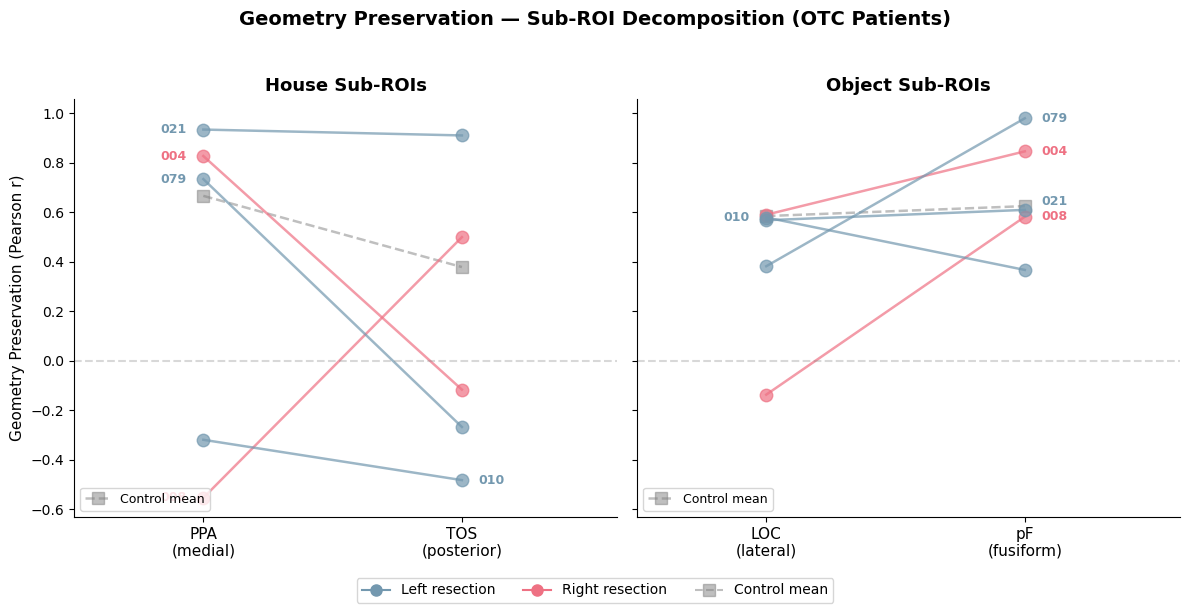

Saved: /user_data/csimmon2/sym_pt/group_results/figures/geometry_subrois.png

Sub-ROI geometry preservation (OTC patients):
  house_PPA: M=0.324, SD=0.703, n=5
  house_TOS: M=0.108, SD=0.578, n=5
  object_LOC: M=0.396, SD=0.310, n=5
  object_pF: M=0.676, SD=0.240, n=5

Sub-ROI geometry preservation (Controls):
  house_PPA: M=0.666, SD=0.377, n=18
  house_TOS: M=0.378, SD=0.561, n=18
  object_LOC: M=0.584, SD=0.343, n=18
  object_pF: M=0.624, SD=0.375, n=18


In [14]:
# CELL: Split-Half Reliability — Slide 8
# ═══════════════════════════════════════════════════════════════════════════════
# Shows within-session split-half reliability (run-1 vs run-2) for symmetric
# vs asymmetric categories. Key point: symmetric ROIs are MORE reliable
# within-session, ruling out noise as explanation for geometry deficit.
# ═══════════════════════════════════════════════════════════════════════════════

sh_file = GEO_DIR / 'split_half_reliability.csv'
sh = pd.read_csv(sh_file)
print(f'Loaded split-half: {len(sh)} rows')

# Filter to primary run pair (first pair per subject/session/category)
sh_primary = (sh.groupby(['subject_id', 'session', 'hemi', 'category'])
                .first().reset_index())

# Filter to canonical 4 categories only
sh_primary = sh_primary[sh_primary['category'].isin(CATEGORIES)].copy()

# Compute per-subject means for symmetric and asymmetric
subj_means = []
for (sid, ses, status), grp in sh_primary.groupby(['subject_id', 'session', 'status']):
    sym_vals  = grp[grp['cat_type'] == 'symmetric']['split_half_r'].dropna()
    asym_vals = grp[grp['cat_type'] == 'asymmetric']['split_half_r'].dropna()
    if len(sym_vals) > 0 and len(asym_vals) > 0:
        subj_means.append({
            'subject_id': sid,
            'session':    ses,
            'status':     status,
            'subject':    grp.iloc[0].get('subject', sid),
            'group':      grp.iloc[0].get('group', ''),
            'surgery_side': grp.iloc[0].get('surgery_side', ''),
            'sym_mean':   sym_vals.mean(),
            'asym_mean':  asym_vals.mean(),
        })
sm = pd.DataFrame(subj_means)

# Use first session per subject for clean display
sm_first = sm.groupby('subject_id').first().reset_index()

patients = sm_first[sm_first['status'] == 'patient'].copy()
controls = sm_first[sm_first['status'] == 'control'].copy()

# ── Label offset helper ───────────────────────────────────────────────────────
def spread_labels(values, min_gap=0.03):
    """Return adjusted y-positions so labels don't overlap."""
    indexed = sorted(enumerate(values), key=lambda x: x[1])
    adjusted = [0.0] * len(values)
    for rank, (orig_idx, val) in enumerate(indexed):
        if rank == 0:
            adjusted[orig_idx] = val
        else:
            prev_idx = indexed[rank - 1][0]
            prev_adj = adjusted[prev_idx]
            adjusted[orig_idx] = max(val, prev_adj + min_gap)
    return adjusted

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 7), sharey=True)

# --- Patients ---
sym_vals_pt = []
labels_pt = []
colors_pt = []

for _, row in patients.iterrows():
    side = str(row.get('surgery_side', ''))
    color = OTC_L if 'left' in side.lower() else OTC_R
    ax1.plot([0, 1], [row['asym_mean'], row['sym_mean']],
             'o-', color=color, alpha=0.7, markersize=8, linewidth=1.5)
    sym_vals_pt.append(row['sym_mean'])
    labels_pt.append(short_name(str(row.get('subject', row['subject_id']))))
    colors_pt.append(color)

# Spread labels on the right side
adjusted_y = spread_labels(sym_vals_pt, min_gap=0.04)
for label, adj_y, color in zip(labels_pt, adjusted_y, colors_pt):
    ax1.annotate(label, (1, adj_y), fontsize=8, color=color, fontweight='bold',
                 xytext=(8, 0), textcoords='offset points', va='center')

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Asymmetric\n(face, word)', 'Symmetric\n(house, object)'],
                     fontsize=10)
ax1.set_ylabel('Split-Half Reliability (Pearson r)', fontsize=11)
ax1.set_title('OTC Patients', fontsize=13, fontweight='bold')
ax1.axhline(0, ls='--', color='grey', alpha=0.3)
ax1.set_xlim(-0.3, 1.6)

# Patient group mean
p_asym_m = patients['asym_mean'].mean()
p_sym_m  = patients['sym_mean'].mean()
ax1.plot([0, 1], [p_asym_m, p_sym_m], 'k-', linewidth=2.5, alpha=0.4, zorder=0)
ax1.plot([0, 1], [p_asym_m, p_sym_m], 'ks', markersize=10, alpha=0.4, zorder=0)

# --- Controls ---
for _, row in controls.iterrows():
    ax2.plot([0, 1], [row['asym_mean'], row['sym_mean']],
             'o-', color=CTRL_R, alpha=0.2, markersize=4, linewidth=0.7)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Asymmetric\n(face, word)', 'Symmetric\n(house, object)'],
                     fontsize=10)
ax2.set_title('Controls', fontsize=13, fontweight='bold')
ax2.axhline(0, ls='--', color='grey', alpha=0.3)
ax2.set_xlim(-0.3, 1.3)

# Control group mean
c_asym_m = controls['asym_mean'].mean()
c_sym_m  = controls['sym_mean'].mean()
ax2.plot([0, 1], [c_asym_m, c_sym_m], 'k-', linewidth=2.5, alpha=0.5, zorder=5)
ax2.plot([0, 1], [c_asym_m, c_sym_m], 'ks', markersize=10, alpha=0.5, zorder=5)
ax2.annotate(f'M={c_asym_m:.2f}', (0, c_asym_m), fontsize=8,
             xytext=(-35, -12), textcoords='offset points', va='center')
ax2.annotate(f'M={c_sym_m:.2f}', (1, c_sym_m), fontsize=8,
             xytext=(8, -12), textcoords='offset points', va='center')

fig.suptitle('Within-Session Split-Half Reliability',
             fontsize=14, fontweight='bold', y=0.97)

# Annotation box with key takeaway
fig.text(0.5, 0.01,
         f'Patients: asym M={p_asym_m:.3f}, sym M={p_sym_m:.3f}  |  '
         f'Controls: asym M={c_asym_m:.3f}, sym M={c_sym_m:.3f}\n'
         f'Symmetric > Asymmetric within-session → '
         f'geometry deficit cannot reflect noise',
         ha='center', fontsize=9, style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'split_half_reliability.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "split_half_reliability.png"}')


# CELL: Sub-ROI Geometry Preservation — Slide 10
# ═══════════════════════════════════════════════════════════════════════════════
# Shows geometry preservation broken down by sub-ROI for house (PPA vs TOS)
# and object (LOC vs pF) in OTC PATIENTS.
# ═══════════════════════════════════════════════════════════════════════════════

geo_file = GEO_DIR / f'geometry_{COPE_SET}.csv'
geo = pd.read_csv(geo_file)
print(f'Loaded geometry: {len(geo)} rows')

SUB_ROIS = ['house_PPA', 'house_TOS', 'object_LOC', 'object_pF']

# ── Diagnostic: what's actually in the data ───────────────────────────────────
print(f'\nAll categories in geometry CSV: {sorted(geo["category"].unique())}')
print(f'All groups: {sorted(geo["group"].unique())}')

otc_all = geo[geo['group'] == 'OTC'].copy()
otc_all = otc_all[~otc_all['subject'].str.contains('017', na=False)]
print(f'\nOTC rows (excl 017): {len(otc_all)}')
print(f'OTC categories: {sorted(otc_all["category"].unique())}')
print(f'OTC subjects: {sorted(otc_all["subject_id"].unique())}')

for sr in SUB_ROIS:
    n = len(otc_all[otc_all['category'] == sr])
    print(f'  {sr}: {n} OTC rows')

# Filter
otc_sub = otc_all[otc_all['category'].isin(SUB_ROIS)].copy()
ctrl_sub = geo[(geo['group'] == 'control') & (geo['category'].isin(SUB_ROIS))].copy()

print(f'\nOTC sub-ROI rows: {len(otc_sub)}')
print(f'Control sub-ROI rows: {len(ctrl_sub)}')

if otc_sub.empty:
    print('\n⚠️  No sub-ROI data for OTC patients!')
    print('    The geometry pipeline may not have computed sub-ROIs for these patients.')
    print('    Check if geometry_differential.csv contains house_PPA/TOS rows for OTC subjects.')
else:
    patients_list = sorted(otc_sub['subject_id'].unique())
    n_pts = len(patients_list)
    print(f'\nPatients with sub-ROI data: {n_pts}')
    for sid in patients_list:
        pt = otc_sub[otc_sub['subject_id'] == sid]
        cats = sorted(pt['category'].unique())
        print(f'  {pt.iloc[0]["subject"]}: {cats}')

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    for panel_idx, (parent, sub_pair, sub_labels) in enumerate([
        ('house', ['house_PPA', 'house_TOS'], ['PPA\n(medial)', 'TOS\n(posterior)']),
        ('object', ['object_LOC', 'object_pF'], ['LOC\n(lateral)', 'pF\n(fusiform)']),
    ]):
        ax = axes[panel_idx]
        cat_a, cat_b = sub_pair

        # Collect values for label spreading
        right_vals = []
        right_labels = []
        right_colors = []
        lines_data = []

        for sid in patients_list:
            pt = otc_sub[otc_sub['subject_id'] == sid]
            a_row = pt[pt['category'] == cat_a]
            b_row = pt[pt['category'] == cat_b]

            if a_row.empty or b_row.empty:
                continue

            a_val = a_row.iloc[0]['geometry_preservation']
            b_val = b_row.iloc[0]['geometry_preservation']
            code = short_name(a_row.iloc[0]['subject'])
            side = str(a_row.iloc[0].get('surgery_side', ''))
            color = OTC_L if 'left' in side.lower() else OTC_R

            lines_data.append((a_val, b_val, color))

            # Decide which end to label (the more extreme end)
            if abs(b_val) + 0.01 < abs(a_val):
                right_vals.append(a_val)
                right_labels.append((code, 0, color))  # label on left
            else:
                right_vals.append(b_val)
                right_labels.append((code, 1, color))  # label on right

        # Draw lines
        for a_val, b_val, color in lines_data:
            ax.plot([0, 1], [a_val, b_val], 'o-', color=color,
                    alpha=0.7, markersize=9, linewidth=1.8)

        # Spread and draw labels
        # Separate left-side and right-side labels
        for label_code, label_side, label_color in right_labels:
            # Find the value
            idx = [l[0] for l in right_labels].index(label_code)
            val = right_vals[idx]

        # Just use sorted spread on all labels at their respective sides
        left_labels = [(c, v, col) for (c, s, col), v in
                       zip(right_labels, right_vals) if s == 0]
        right_only  = [(c, v, col) for (c, s, col), v in
                       zip(right_labels, right_vals) if s == 1]

        if left_labels:
            sorted_left = sorted(left_labels, key=lambda x: x[1])
            adj = spread_labels([x[1] for x in sorted_left], min_gap=0.06)
            for (code, _, color), ay in zip(sorted_left, adj):
                ax.annotate(code, (-0.02, ay), fontsize=9, color=color,
                            fontweight='bold', ha='right', va='center',
                            xytext=(-8, 0), textcoords='offset points')

        if right_only:
            sorted_right = sorted(right_only, key=lambda x: x[1])
            adj = spread_labels([x[1] for x in sorted_right], min_gap=0.06)
            for (code, _, color), ay in zip(sorted_right, adj):
                ax.annotate(code, (1.02, ay), fontsize=9, color=color,
                            fontweight='bold', ha='left', va='center',
                            xytext=(8, 0), textcoords='offset points')

        # Control means for reference
        ctrl_a = ctrl_sub[ctrl_sub['category'] == cat_a]['geometry_preservation'].dropna()
        ctrl_b = ctrl_sub[ctrl_sub['category'] == cat_b]['geometry_preservation'].dropna()
        if len(ctrl_a) > 0 and len(ctrl_b) > 0:
            ax.plot([0, 1], [ctrl_a.mean(), ctrl_b.mean()], 's--',
                    color='grey', alpha=0.5, markersize=9, linewidth=1.8,
                    label=f'Control mean', zorder=0)
            ax.legend(loc='lower left', fontsize=9)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(sub_labels, fontsize=11)
        ax.set_title(f'{parent.capitalize()} Sub-ROIs',
                     fontsize=13, fontweight='bold')
        ax.axhline(0, ls='--', color='grey', alpha=0.3)
        ax.set_xlim(-0.5, 1.6)

    axes[0].set_ylabel('Geometry Preservation (Pearson r)', fontsize=11)

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color=OTC_L, label='Left resection',
               markersize=8, linewidth=1.5),
        Line2D([0], [0], marker='o', color=OTC_R, label='Right resection',
               markersize=8, linewidth=1.5),
        Line2D([0], [0], marker='s', color='grey', label='Control mean',
               markersize=8, linewidth=1.5, linestyle='--', alpha=0.5),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=10, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle('Geometry Preservation — Sub-ROI Decomposition (OTC Patients)',
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    plt.savefig(FIG_DIR / 'geometry_subrois.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIG_DIR / "geometry_subrois.png"}')

    # ── Summary ───────────────────────────────────────────────────────────
    print('\nSub-ROI geometry preservation (OTC patients):')
    for cat in SUB_ROIS:
        vals = otc_sub[otc_sub['category'] == cat]['geometry_preservation'].dropna()
        if len(vals) > 0:
            print(f'  {cat}: M={vals.mean():.3f}, SD={vals.std():.3f}, n={len(vals)}')

    print('\nSub-ROI geometry preservation (Controls):')
    for cat in SUB_ROIS:
        vals = ctrl_sub[ctrl_sub['category'] == cat]['geometry_preservation'].dropna()
        if len(vals) > 0:
            print(f'  {cat}: M={vals.mean():.3f}, SD={vals.std():.3f}, n={len(vals)}')

Loaded geometry: 329 rows
OTC sub-ROI rows: 36
  face_FFA: 5 OTC rows
  face_STS: 4 OTC rows
  word_VWFA: 3 OTC rows
  word_STG: 4 OTC rows
  house_PPA: 5 OTC rows
  house_TOS: 5 OTC rows
  object_LOC: 5 OTC rows
  object_pF: 5 OTC rows

Patients with sub-ROI data: 5


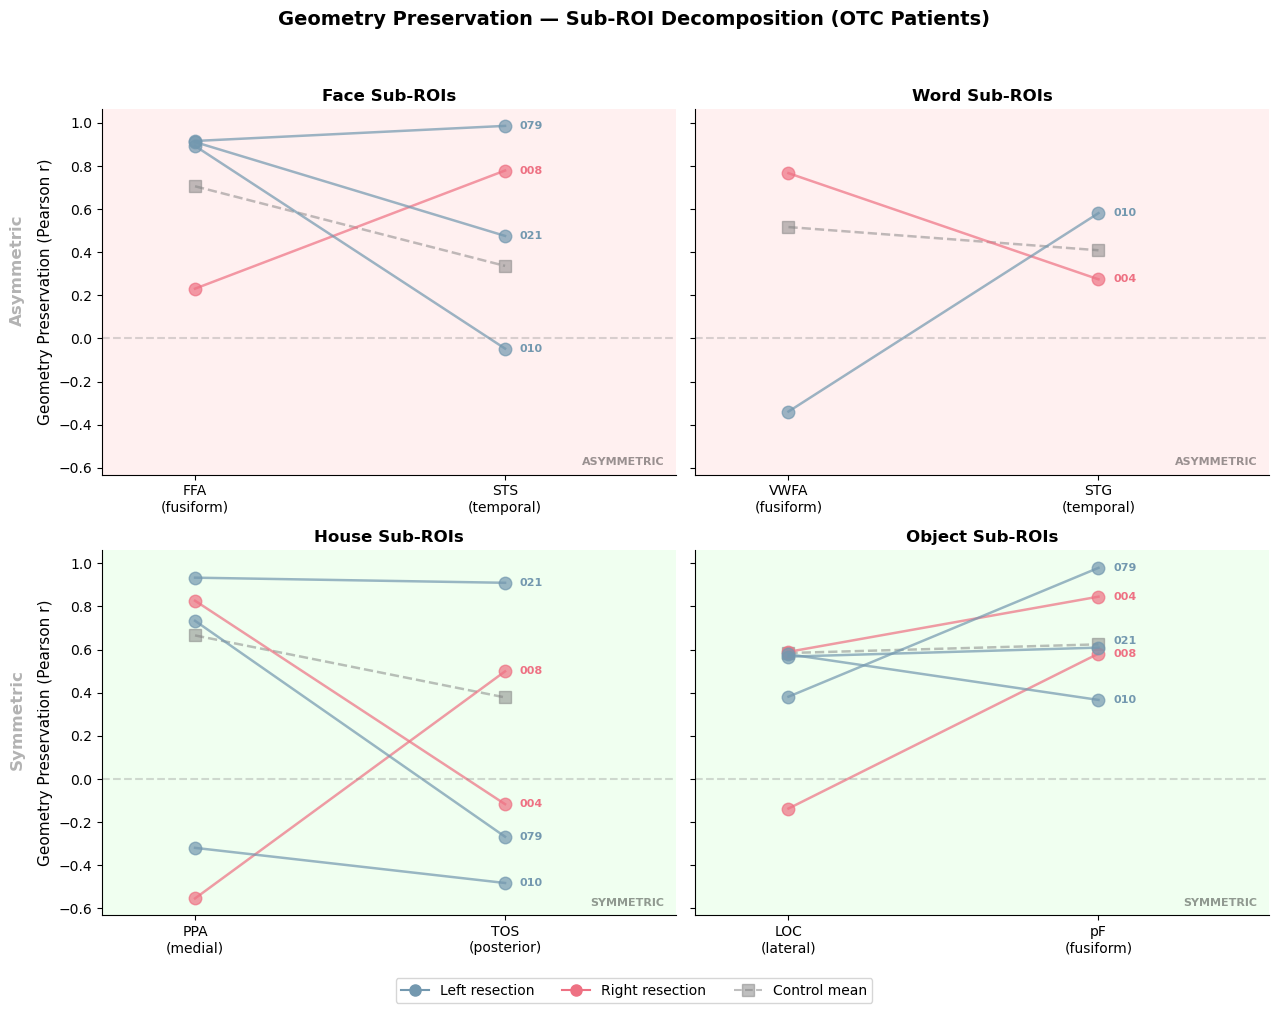

Saved: /user_data/csimmon2/sym_pt/group_results/figures/geometry_subrois_all8.png

Sub-ROI geometry preservation summary

Sub-ROI        Type            OTC M   OTC SD    n    Ctrl M  Ctrl SD    n
----------------------------------------------------------------------
  face_FFA     asymmetric      0.745    0.293    5     0.706    0.287   18
  face_STS     asymmetric      0.548    0.449    4     0.337    0.480   18
  word_VWFA    asymmetric      0.139    0.568    3     0.517    0.482   12
  word_STG     asymmetric      0.434    0.239    4     0.409    0.425   18
  house_PPA    symmetric       0.324    0.703    5     0.666    0.377   18
  house_TOS    symmetric       0.108    0.578    5     0.378    0.561   18
  object_LOC   symmetric       0.396    0.310    5     0.584    0.343   18
  object_pF    symmetric       0.676    0.240    5     0.624    0.375   18


In [15]:
# CELL: Sub-ROI Geometry Preservation — All 8 Sub-ROIs (2×2)
# ═══════════════════════════════════════════════════════════════════════════════
# Top row: Asymmetric sub-ROIs (face: FFA vs STS, word: VWFA vs STG)
# Bottom row: Symmetric sub-ROIs (house: PPA vs TOS, object: LOC vs pF)
# ═══════════════════════════════════════════════════════════════════════════════

geo_file = GEO_DIR / f'geometry_{COPE_SET}.csv'
geo = pd.read_csv(geo_file)
print(f'Loaded geometry: {len(geo)} rows')

ALL_SUB_ROIS = ['face_FFA', 'face_STS', 'word_VWFA', 'word_STG',
                'house_PPA', 'house_TOS', 'object_LOC', 'object_pF']

# Filter OTC patients (excl 017)
otc_all = geo[geo['group'] == 'OTC'].copy()
otc_all = otc_all[~otc_all['subject'].str.contains('017', na=False)]
otc_sub = otc_all[otc_all['category'].isin(ALL_SUB_ROIS)].copy()
ctrl_sub = geo[(geo['group'] == 'control') & (geo['category'].isin(ALL_SUB_ROIS))].copy()

# Diagnostic
print(f'OTC sub-ROI rows: {len(otc_sub)}')
for sr in ALL_SUB_ROIS:
    n = len(otc_sub[otc_sub['category'] == sr])
    print(f'  {sr}: {n} OTC rows')

patients_list = sorted(otc_sub['subject_id'].unique())
print(f'\nPatients with sub-ROI data: {len(patients_list)}')

# ── Label spread helper ───────────────────────────────────────────────────────
def spread_labels(values, min_gap=0.06):
    indexed = sorted(enumerate(values), key=lambda x: x[1])
    adjusted = [0.0] * len(values)
    for rank, (orig_idx, val) in enumerate(indexed):
        if rank == 0:
            adjusted[orig_idx] = val
        else:
            prev_idx = indexed[rank - 1][0]
            prev_adj = adjusted[prev_idx]
            adjusted[orig_idx] = max(val, prev_adj + min_gap)
    return adjusted

# ── Panel config ──────────────────────────────────────────────────────────────
panels = [
    # (title, cat_a, cat_b, label_a, label_b, cat_type)
    ('Face Sub-ROIs',   'face_FFA',   'face_STS',   'FFA\n(fusiform)',   'STS\n(temporal)',  'asymmetric'),
    ('Word Sub-ROIs',   'word_VWFA',  'word_STG',   'VWFA\n(fusiform)',  'STG\n(temporal)',  'asymmetric'),
    ('House Sub-ROIs',  'house_PPA',  'house_TOS',  'PPA\n(medial)',     'TOS\n(posterior)', 'symmetric'),
    ('Object Sub-ROIs', 'object_LOC', 'object_pF',  'LOC\n(lateral)',    'pF\n(fusiform)',   'symmetric'),
]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True)

for panel_idx, (title, cat_a, cat_b, lab_a, lab_b, cat_type) in enumerate(panels):
    row, col = divmod(panel_idx, 2)
    ax = axes[row, col]

    # Background tint
    bg_color = '#fff0f0' if cat_type == 'asymmetric' else '#f0fff0'
    ax.set_facecolor(bg_color)

    right_vals = []
    right_info = []  # (code, color)
    left_vals = []
    left_info = []

    for sid in patients_list:
        pt = otc_sub[otc_sub['subject_id'] == sid]
        a_row = pt[pt['category'] == cat_a]
        b_row = pt[pt['category'] == cat_b]

        if a_row.empty or b_row.empty:
            continue

        a_val = a_row.iloc[0]['geometry_preservation']
        b_val = b_row.iloc[0]['geometry_preservation']
        code = short_name(a_row.iloc[0]['subject'])
        side = str(a_row.iloc[0].get('surgery_side', ''))
        color = OTC_L if 'left' in side.lower() else OTC_R

        ax.plot([0, 1], [a_val, b_val], 'o-', color=color,
                alpha=0.7, markersize=9, linewidth=1.8)

        # Label on both sides for clarity
        left_vals.append(a_val)
        left_info.append((code, color))
        right_vals.append(b_val)
        right_info.append((code, color))

    # Spread labels - right side
    if right_vals:
        adj_r = spread_labels(right_vals, min_gap=0.06)
        for (code, color), ay in zip(right_info, adj_r):
            ax.annotate(code, (1.02, ay), fontsize=8, color=color,
                        fontweight='bold', ha='left', va='center',
                        xytext=(6, 0), textcoords='offset points')

    # Control means
    ctrl_a = ctrl_sub[ctrl_sub['category'] == cat_a]['geometry_preservation'].dropna()
    ctrl_b = ctrl_sub[ctrl_sub['category'] == cat_b]['geometry_preservation'].dropna()
    if len(ctrl_a) > 0 and len(ctrl_b) > 0:
        ax.plot([0, 1], [ctrl_a.mean(), ctrl_b.mean()], 's--',
                color='grey', alpha=0.5, markersize=9, linewidth=1.8, zorder=0)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([lab_a, lab_b], fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axhline(0, ls='--', color='grey', alpha=0.3)
    ax.set_xlim(-0.3, 1.55)

    # Type label in corner
    ax.text(0.98, 0.02, cat_type.upper(), transform=ax.transAxes,
            fontsize=8, ha='right', va='bottom', alpha=0.4, fontweight='bold')

axes[0, 0].set_ylabel('Geometry Preservation (Pearson r)', fontsize=11)
axes[1, 0].set_ylabel('Geometry Preservation (Pearson r)', fontsize=11)

# Row labels
fig.text(0.02, 0.73, 'Asymmetric', fontsize=12, fontweight='bold',
         rotation=90, va='center', alpha=0.3)
fig.text(0.02, 0.28, 'Symmetric', fontsize=12, fontweight='bold',
         rotation=90, va='center', alpha=0.3)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color=OTC_L, label='Left resection',
           markersize=8, linewidth=1.5),
    Line2D([0], [0], marker='o', color=OTC_R, label='Right resection',
           markersize=8, linewidth=1.5),
    Line2D([0], [0], marker='s', color='grey', label='Control mean',
           markersize=8, linewidth=1.5, linestyle='--', alpha=0.5),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Geometry Preservation — Sub-ROI Decomposition (OTC Patients)',
             fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.96])
plt.savefig(FIG_DIR / 'geometry_subrois_all8.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "geometry_subrois_all8.png"}')

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n' + '='*70)
print('Sub-ROI geometry preservation summary')
print('='*70)
print(f'\n{"Sub-ROI":<14} {"Type":<12} {"OTC M":>8} {"OTC SD":>8} {"n":>4}  {"Ctrl M":>8} {"Ctrl SD":>8} {"n":>4}')
print('-'*70)
for cat in ALL_SUB_ROIS:
    parent = cat.split('_')[0]
    ctype = 'symmetric' if parent in BILATERAL else 'asymmetric'
    otc_vals = otc_sub[otc_sub['category'] == cat]['geometry_preservation'].dropna()
    ctrl_vals = ctrl_sub[ctrl_sub['category'] == cat]['geometry_preservation'].dropna()
    otc_m  = f'{otc_vals.mean():.3f}' if len(otc_vals) > 0 else '   N/A'
    otc_s  = f'{otc_vals.std():.3f}' if len(otc_vals) > 0 else '   N/A'
    ctrl_m = f'{ctrl_vals.mean():.3f}' if len(ctrl_vals) > 0 else '   N/A'
    ctrl_s = f'{ctrl_vals.std():.3f}' if len(ctrl_vals) > 0 else '   N/A'
    print(f'  {cat:<12} {ctype:<12} {otc_m:>8} {otc_s:>8} {len(otc_vals):>4}  {ctrl_m:>8} {ctrl_s:>8} {len(ctrl_vals):>4}')